In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [2]:
obj <- readRDS("cellplex1_soupX.rds")

In [13]:
hvg <- read.csv("cellplex1.bigsur.hvg.csv", row.names = 1)

In [4]:
meta <- read.csv("cellplex1.adata.obs.metadata.csv", row.names=1)
as.data.frame(colnames(meta))

colnames(meta)
<chr>
orig_ident
n_genes
n_genes_by_counts
log1p_n_genes_by_counts
total_counts
log1p_total_counts
pct_counts_in_top_50_genes
pct_counts_in_top_100_genes
pct_counts_in_top_200_genes


In [5]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTACAGTTC-1,nMFP_1,1.3283905,31.01637,0,6,Bcells
AAACGAATCAGTGTCA-1,nMFP_1,1.6458458,30.51755,0,7,Tcells
AAACGAATCCTTATCA-1,nMFP_1,0.7378259,23.21692,0,6,Bcells
AAACGCTTCCTGCTAC-1,nMFP_1,1.6158458,28.22517,0,7,Tcells
AAAGAACTCTTACGGA-1,nMFP_1,1.3463132,21.58244,0,6,Bcells
AAAGGATGTATTCCTT-1,nMFP_1,1.2118987,24.60522,0,6,Bcells


In [6]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTACAGTTC-1,SeuratProject,3130.784,1429,nMFP_1,1.3283905,31.01637,0,6,Bcells
AAACGAATCAGTGTCA-1,SeuratProject,4857.440,1940,nMFP_1,1.6458458,30.51755,0,7,Tcells
AAACGAATCCTTATCA-1,SeuratProject,1976.821,1146,nMFP_1,0.7378259,23.21692,0,6,Bcells
AAACGCTTCCTGCTAC-1,SeuratProject,7342.814,2591,nMFP_1,1.6158458,28.22517,0,7,Tcells
AAAGAACTCTTACGGA-1,SeuratProject,4638.573,2012,nMFP_1,1.3463132,21.58244,0,6,Bcells
AAAGGATGTATTCCTT-1,SeuratProject,2638.452,1284,nMFP_1,1.2118987,24.60522,0,6,Bcells


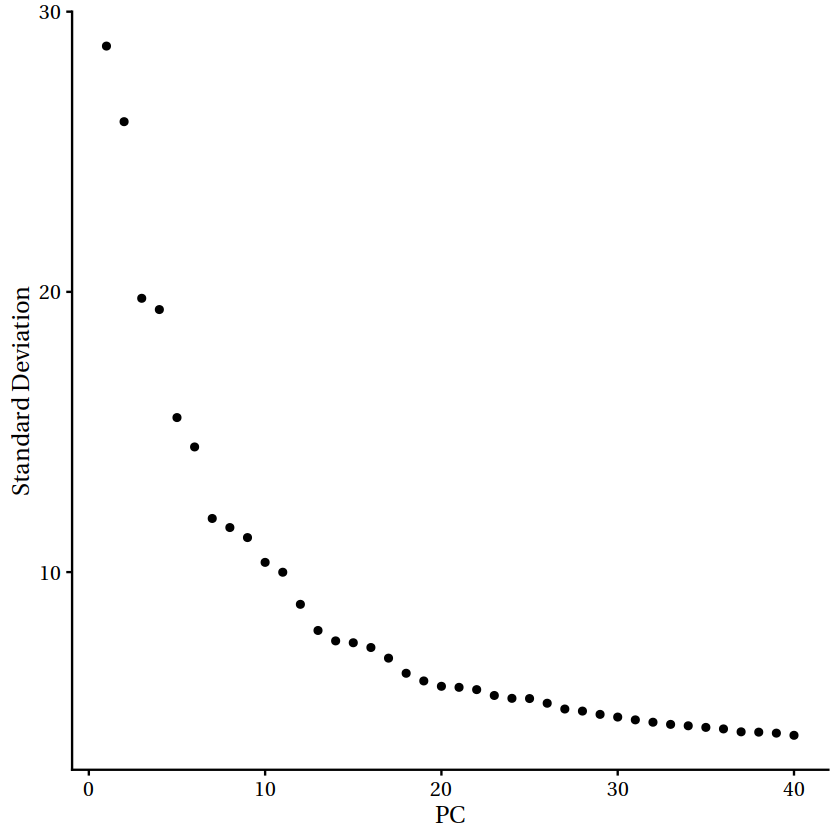

In [7]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


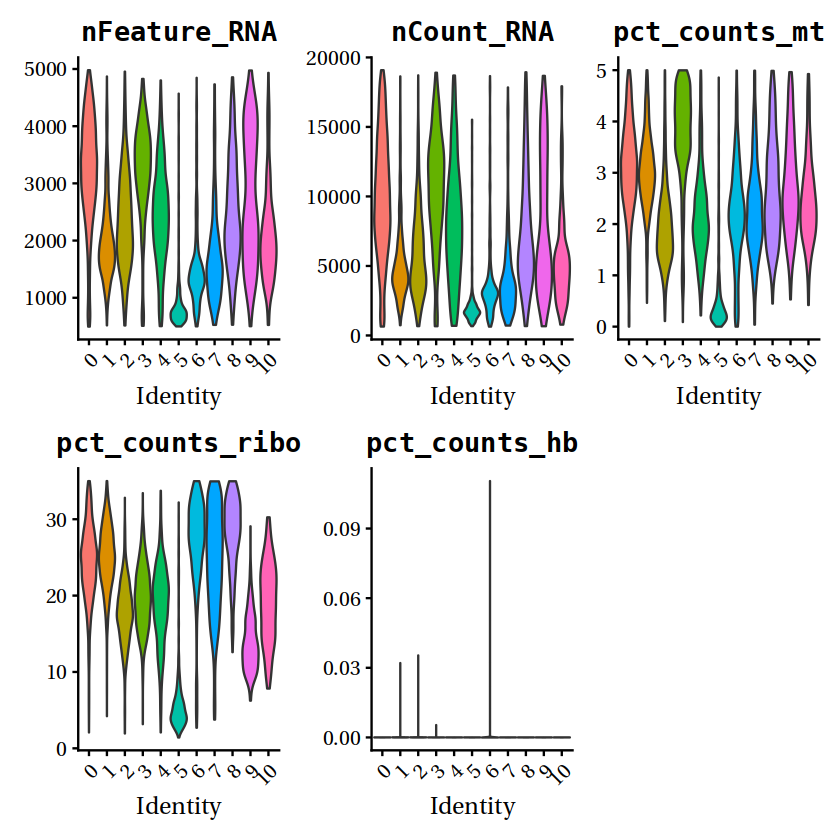

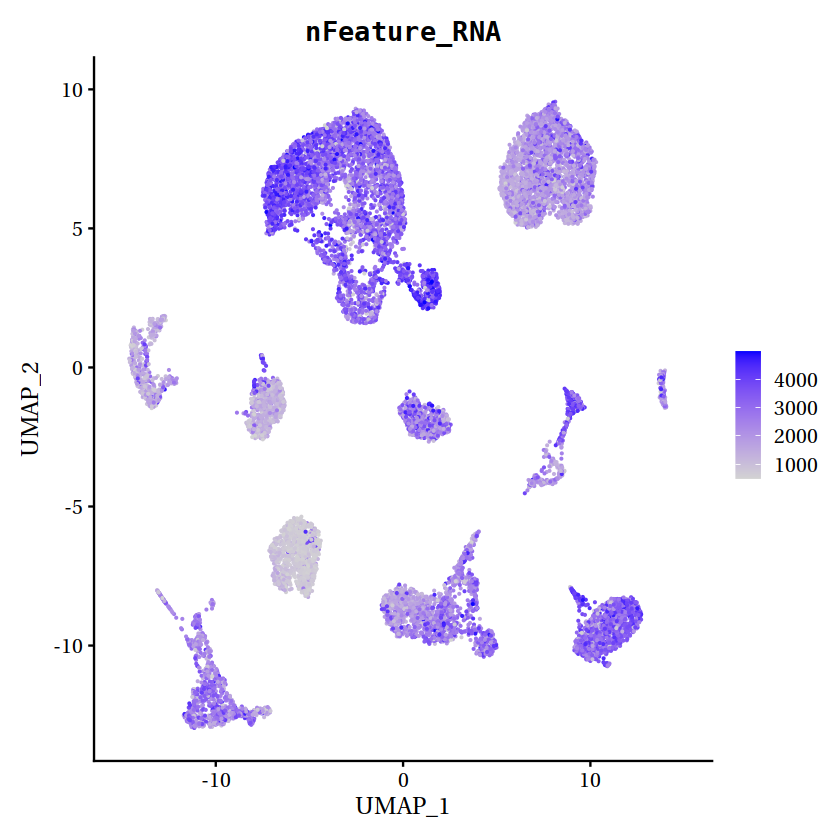

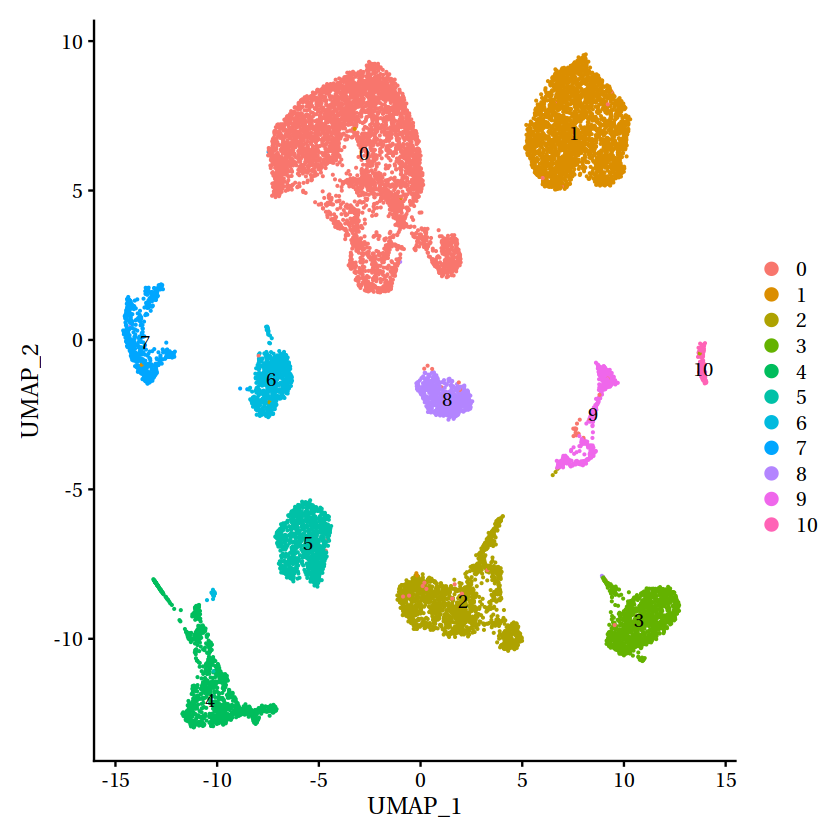

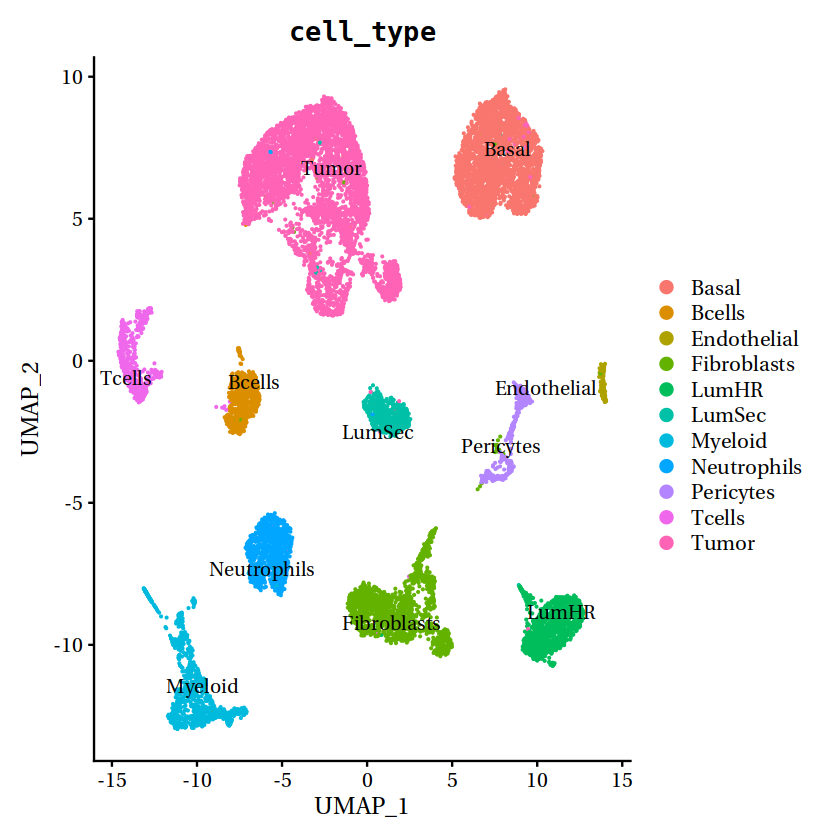

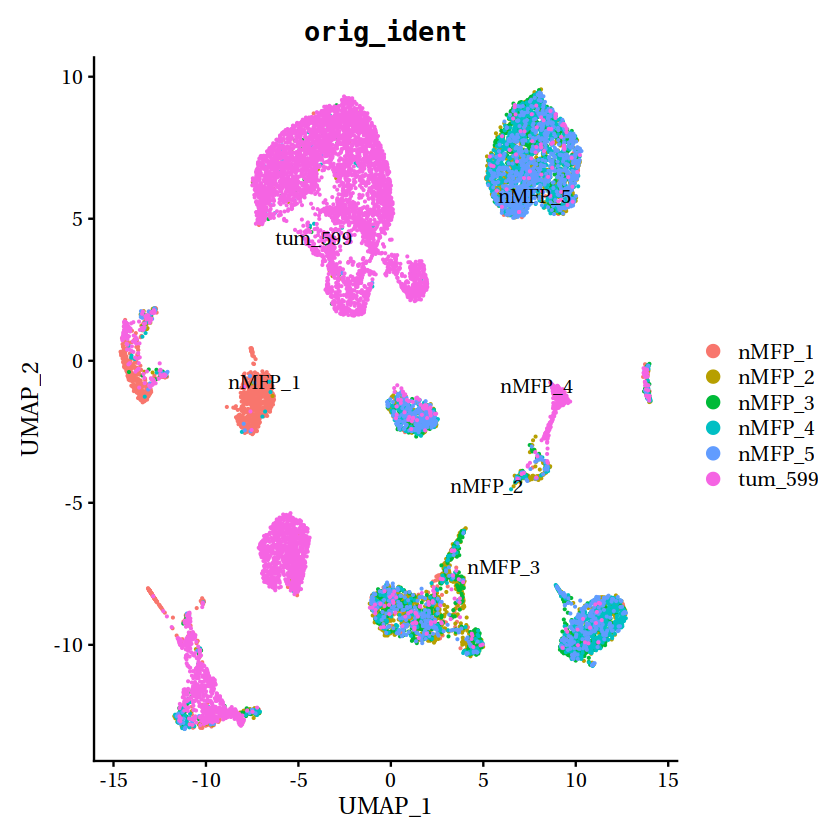

In [8]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = T, repel = T)

In [15]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 1500, WhichCells(obj, ident = c(0,3)), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 1500, WhichCells(obj, ident = c(5)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3000, WhichCells(obj, ident = c(6)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3500, WhichCells(obj, ident = c(1,7,10)), invert = TRUE)

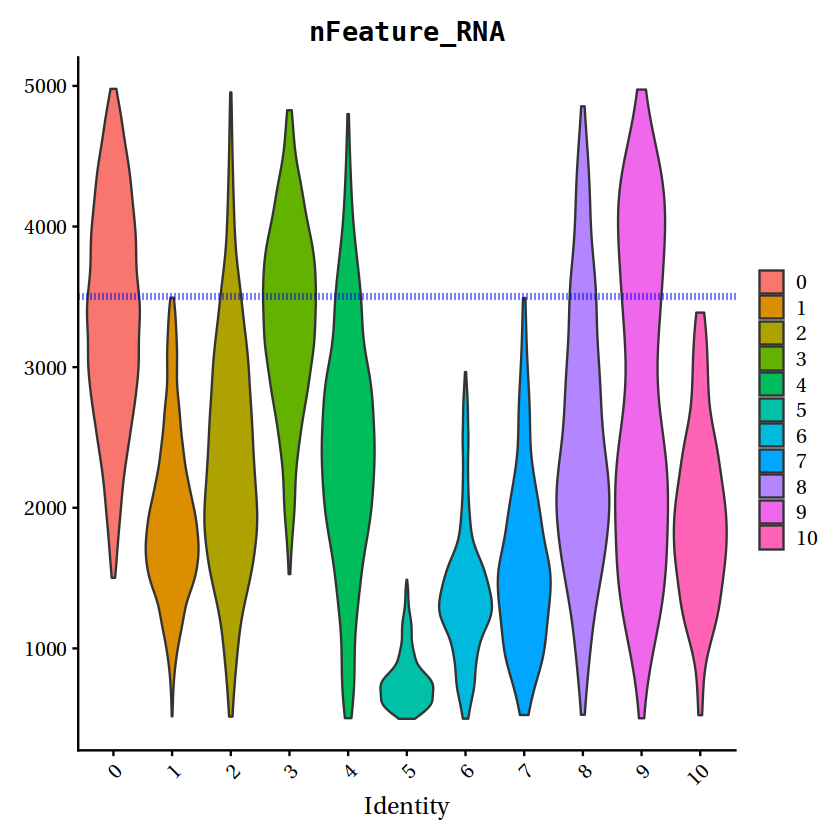

In [16]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 3500, linetype="dotted", 
                color = "blue", size=1.5)

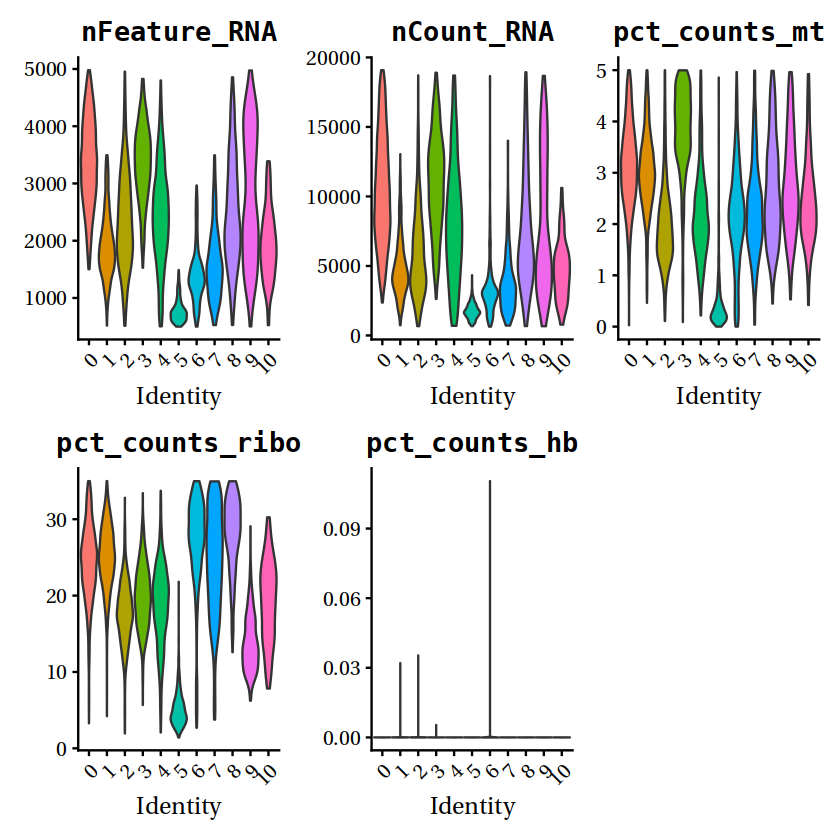

In [17]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

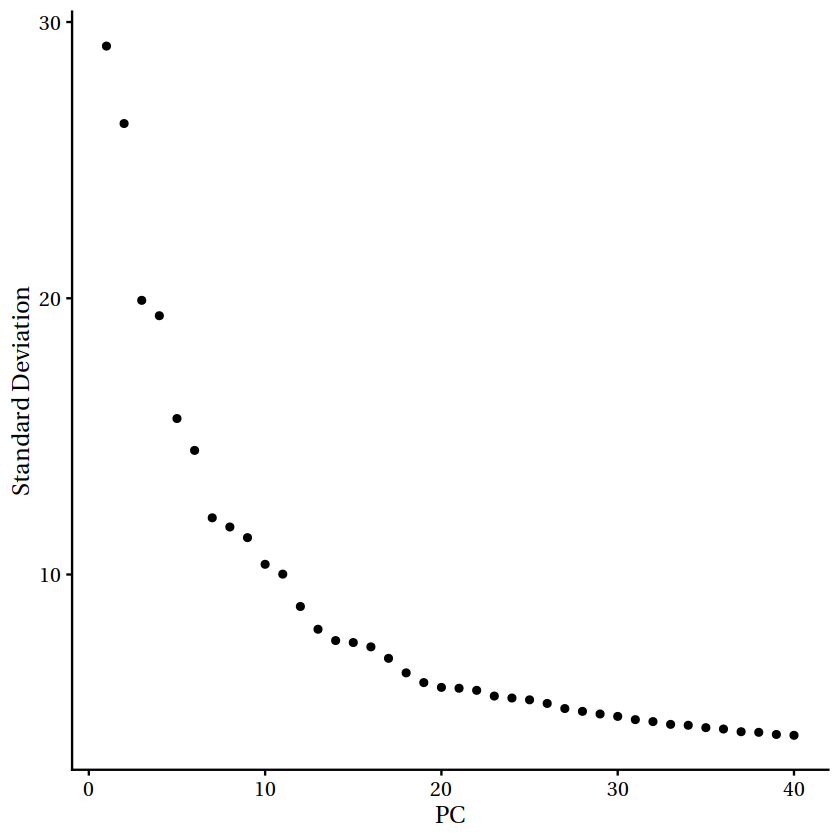

In [18]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

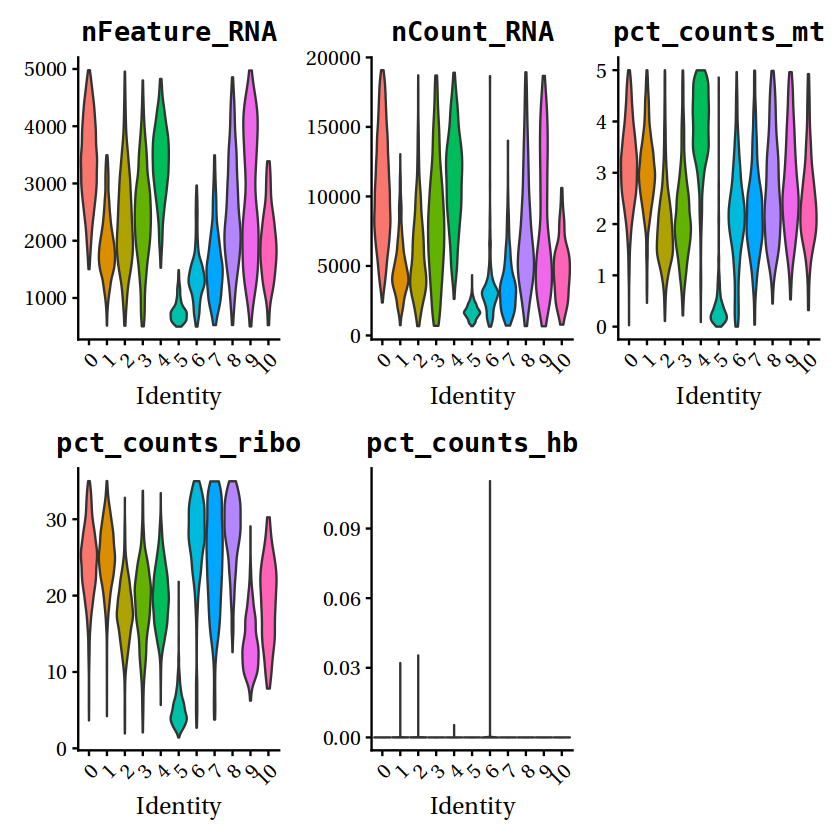

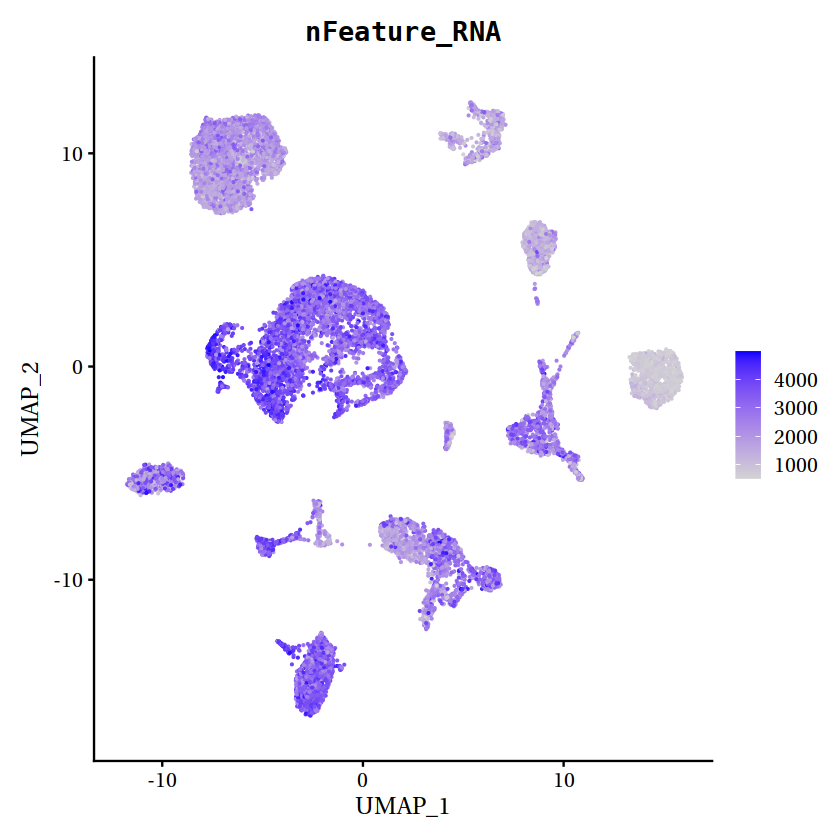

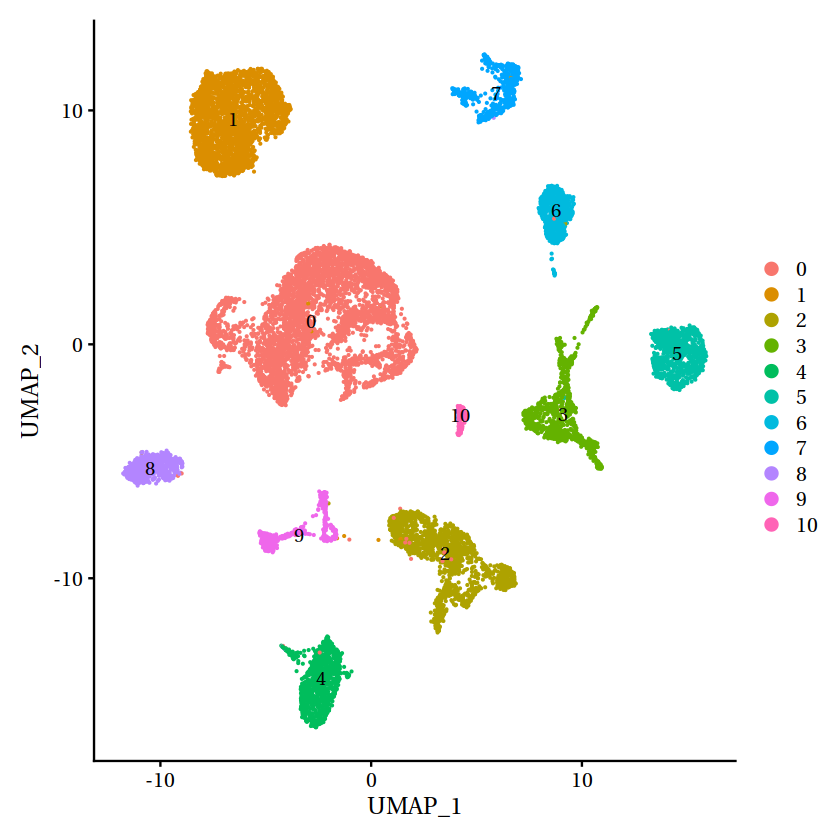

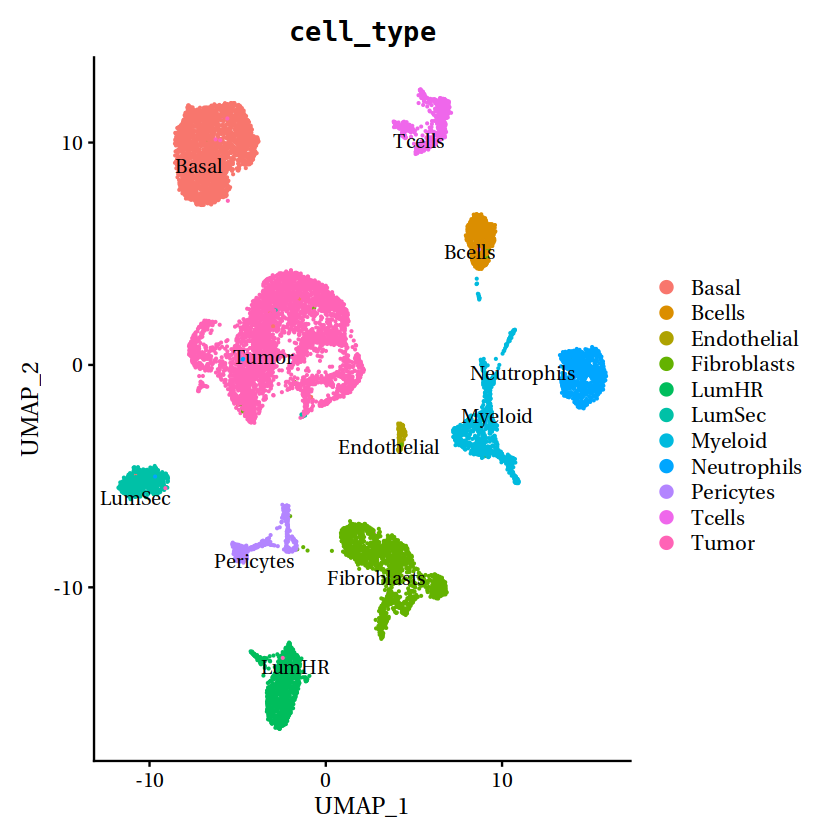

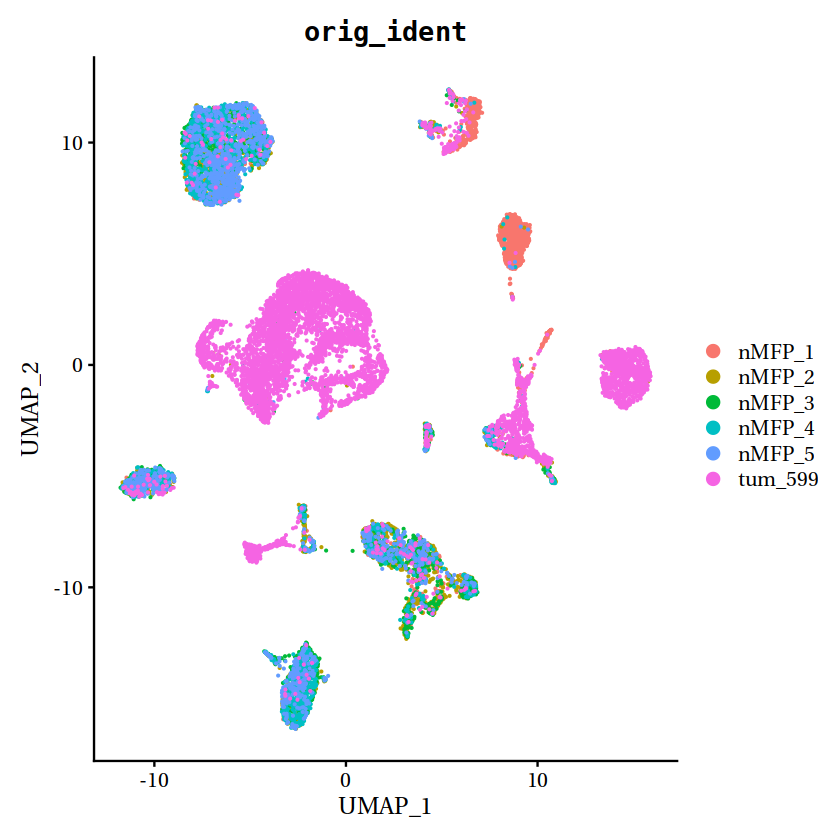

In [19]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [20]:
saveRDS(obj, "cellplex1_soupX.rds")

### after doublet prediction

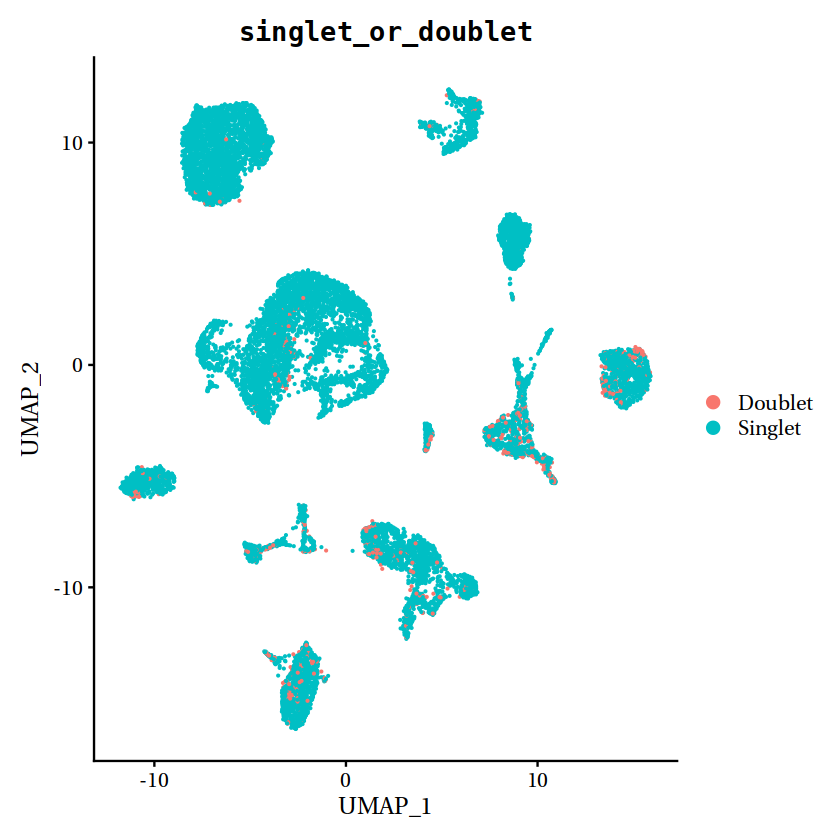

In [3]:
obj <- readRDS("cellplex1_soupX.rds")
DimPlot(obj, group.by = "singlet_or_doublet")

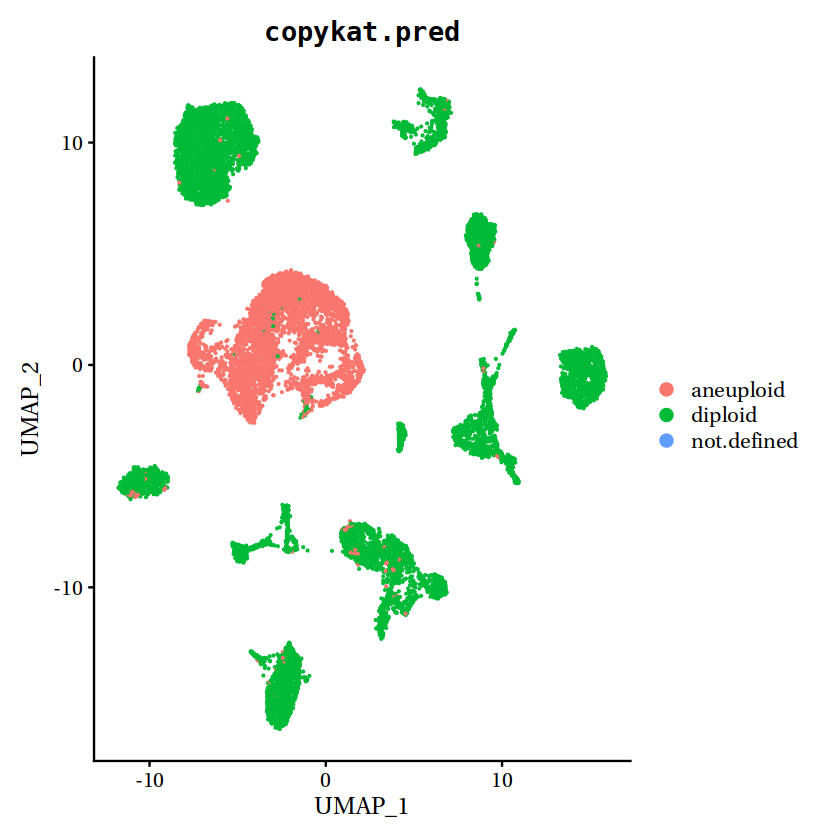

In [4]:
pred <- read.csv("cellplex_1_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="copykat.pred")

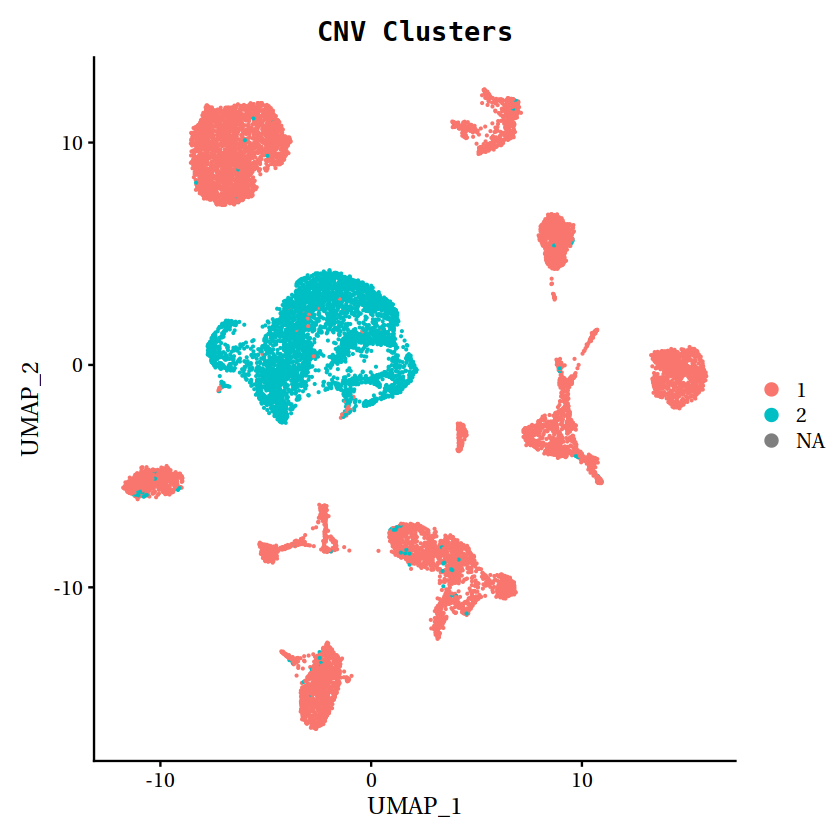

In [28]:
clust_res <- readRDS("cellplex_1_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 2, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

#### normal clean up

In [6]:
sub <- subset(obj, subset = orig_ident == "tum_599", invert = T)

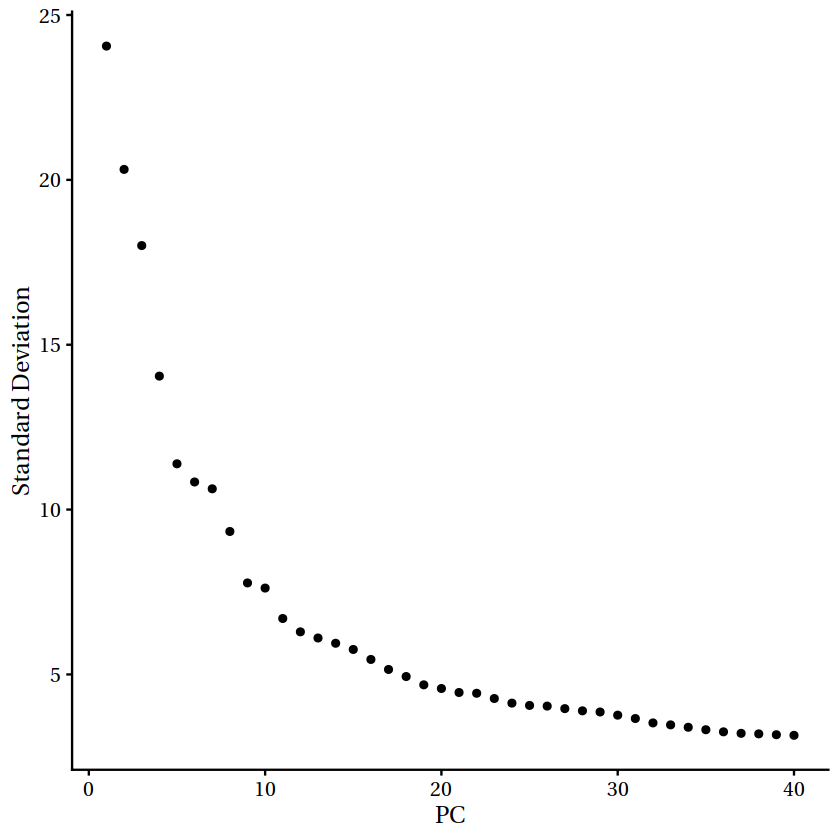

In [14]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

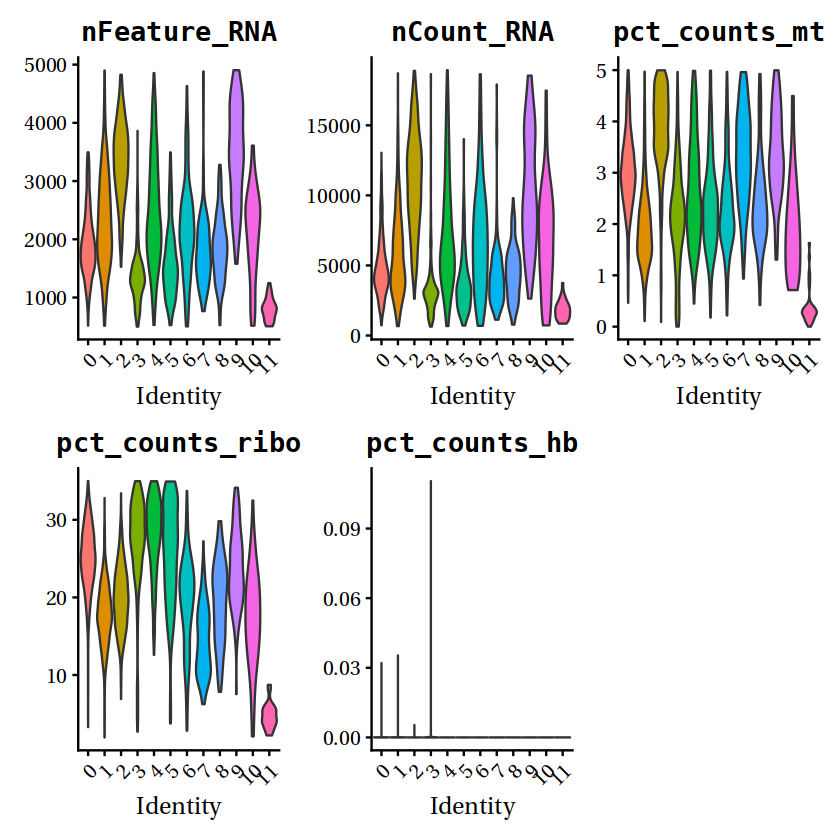

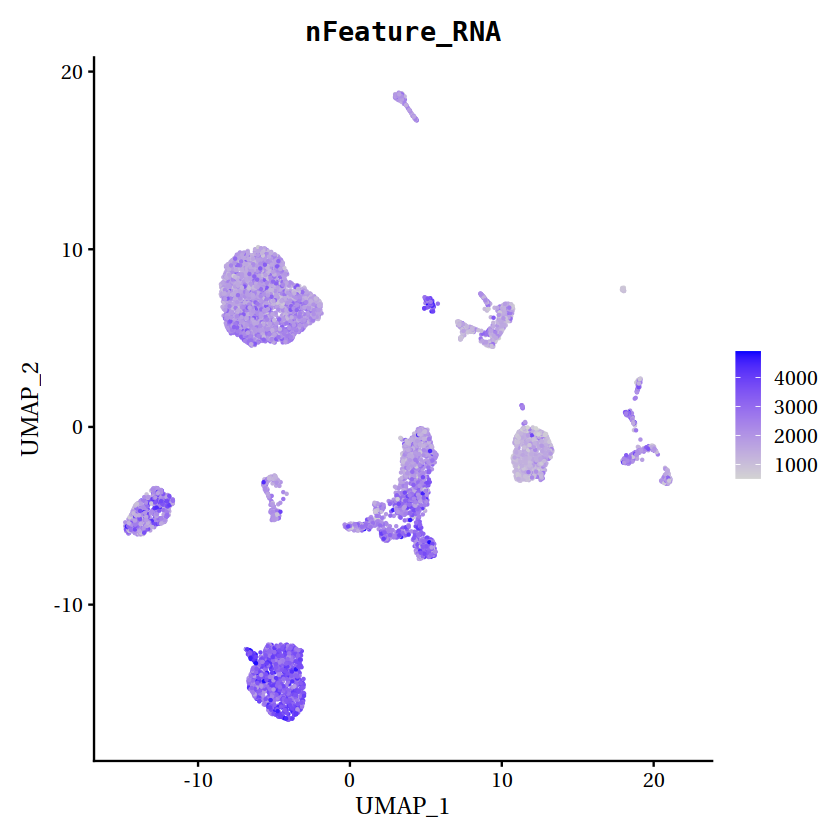

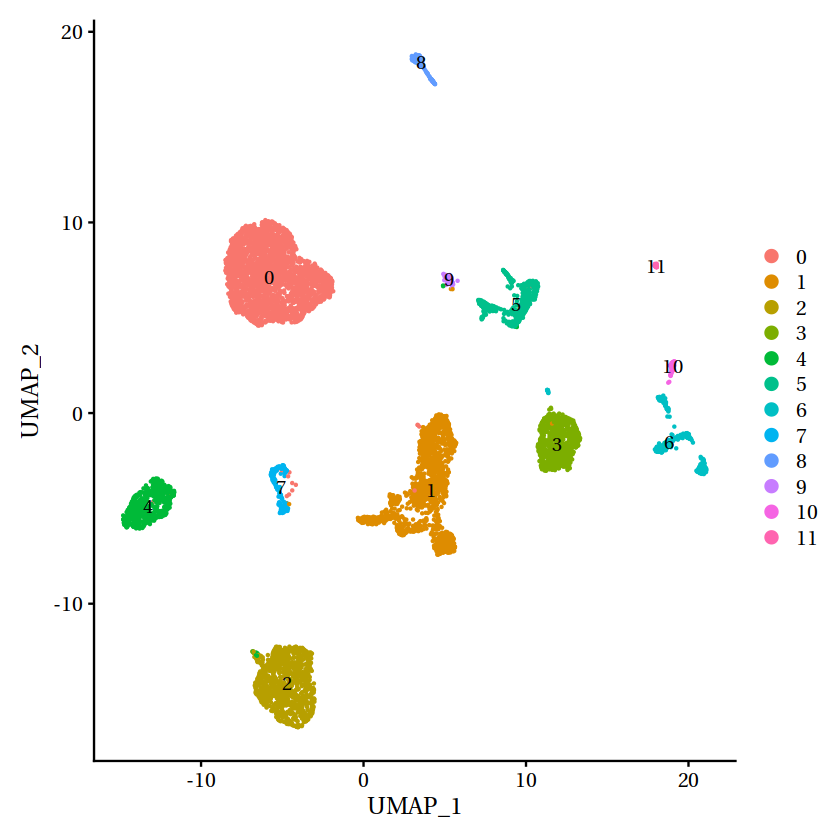

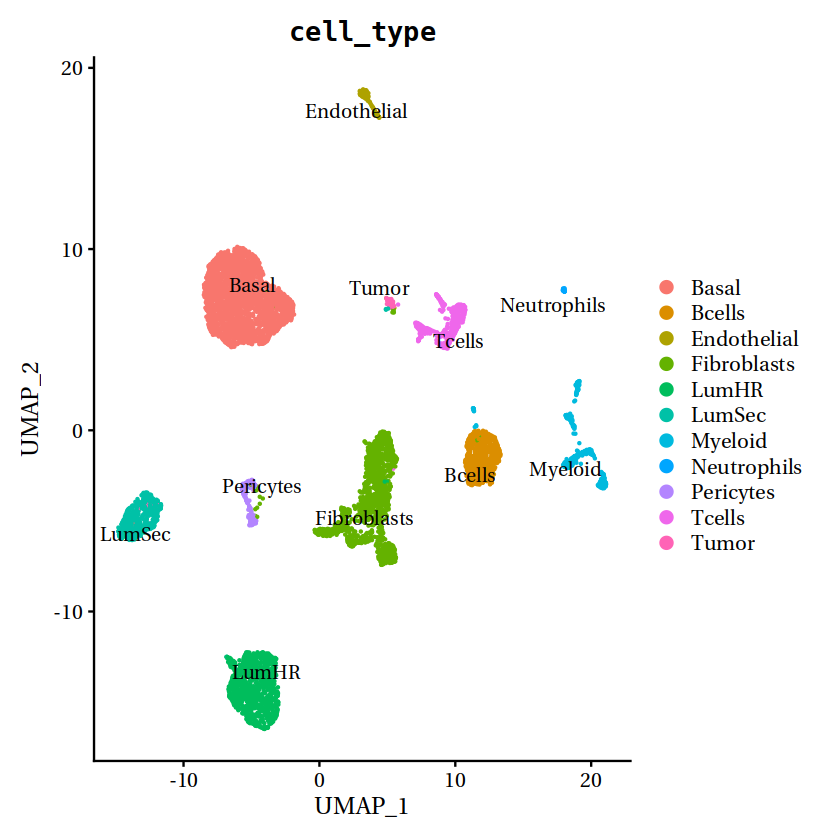

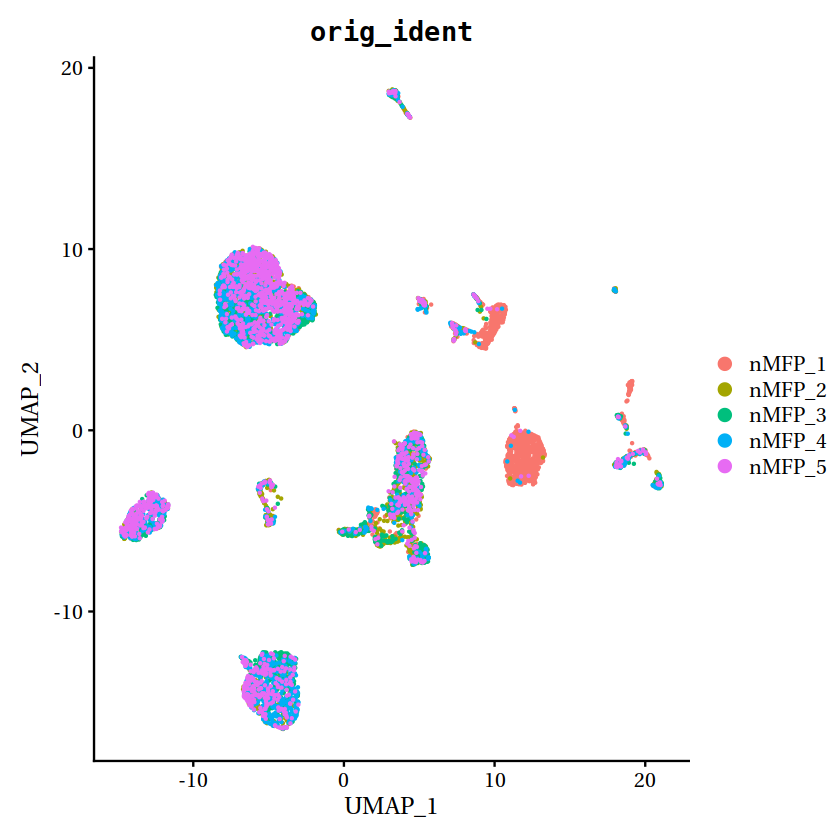

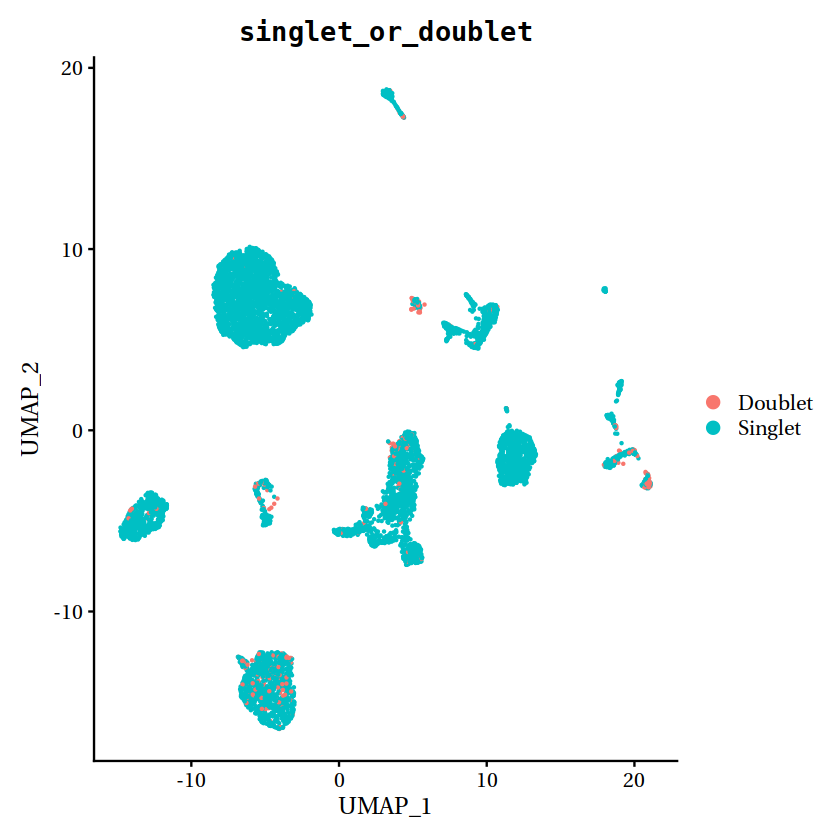

In [16]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.15, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

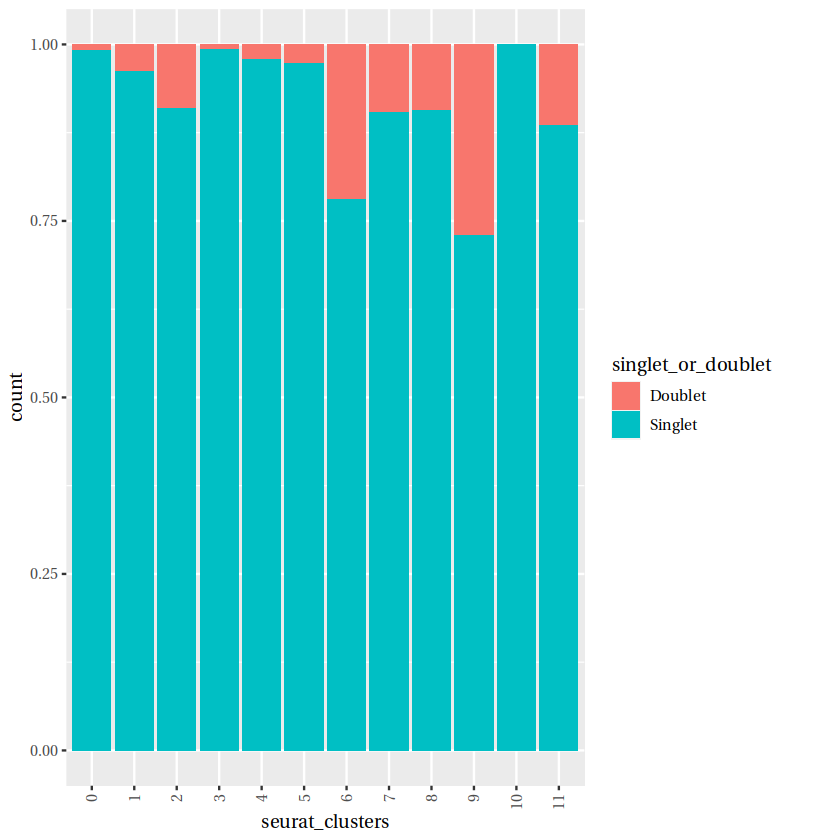

In [17]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

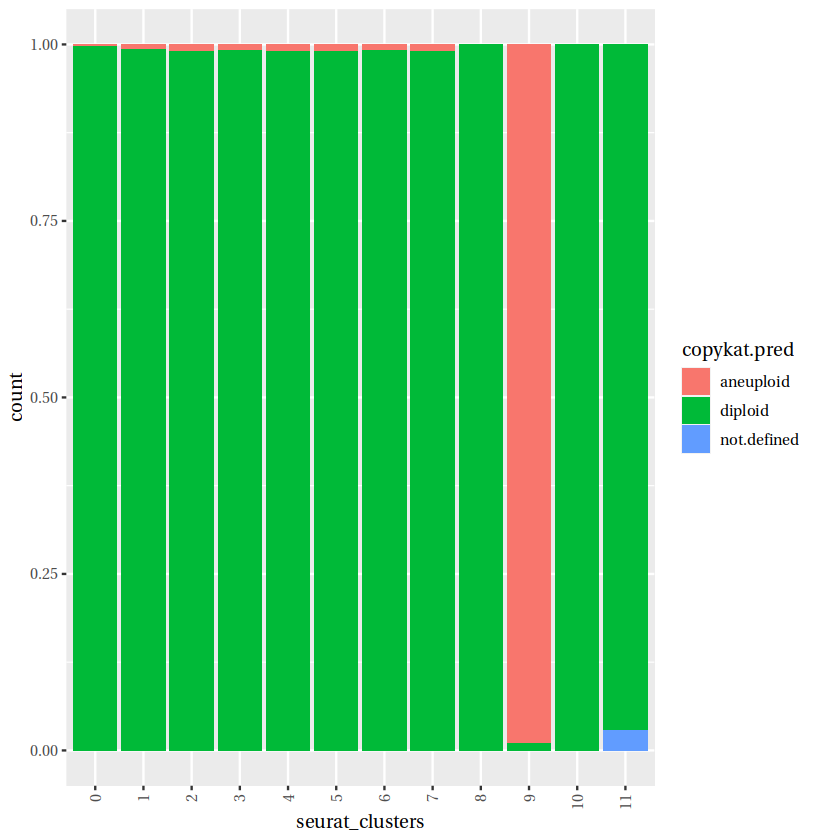

In [18]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [19]:
garbage <- subset(sub, subset = seurat_clusters == "9")
garbage
write.csv(colnames(garbage), "mouse1_garbage_doublets.csv")

An object of class Seurat 
64570 features across 100 samples within 2 assays 
Active assay: SCT (32285 features, 1127 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

### check but don't save tumor 599

In [20]:
sub <- subset(obj, subset = orig_ident == "tum_599")

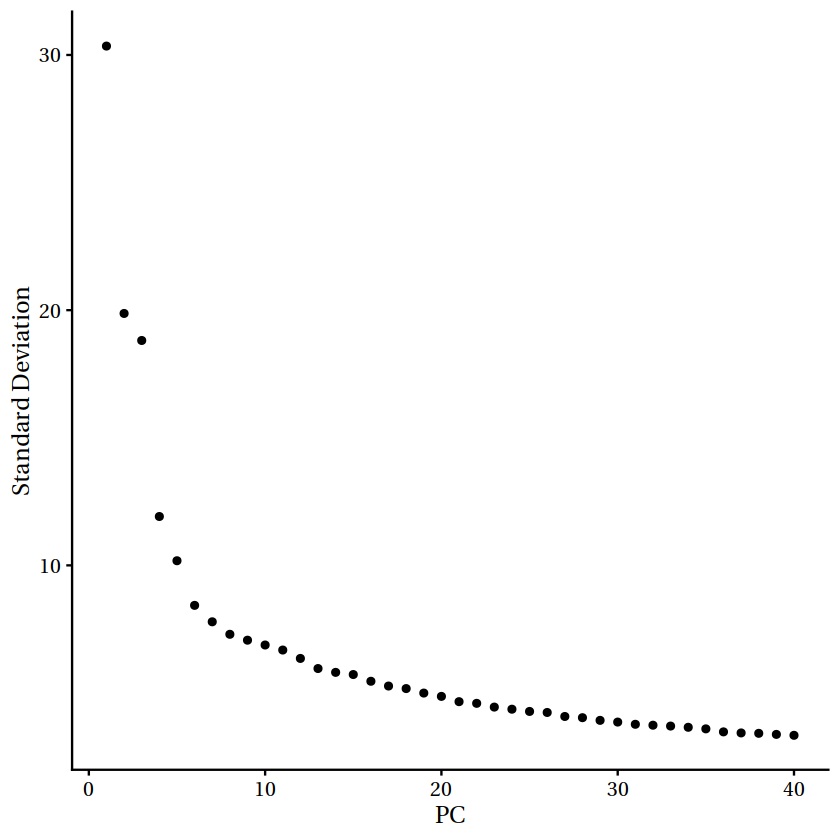

In [21]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


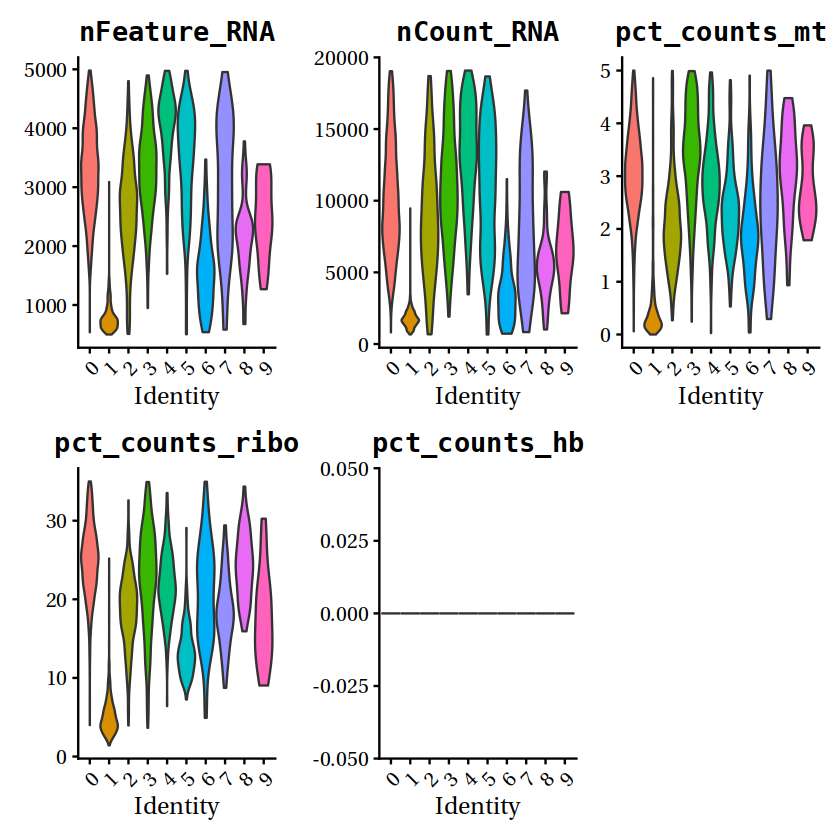

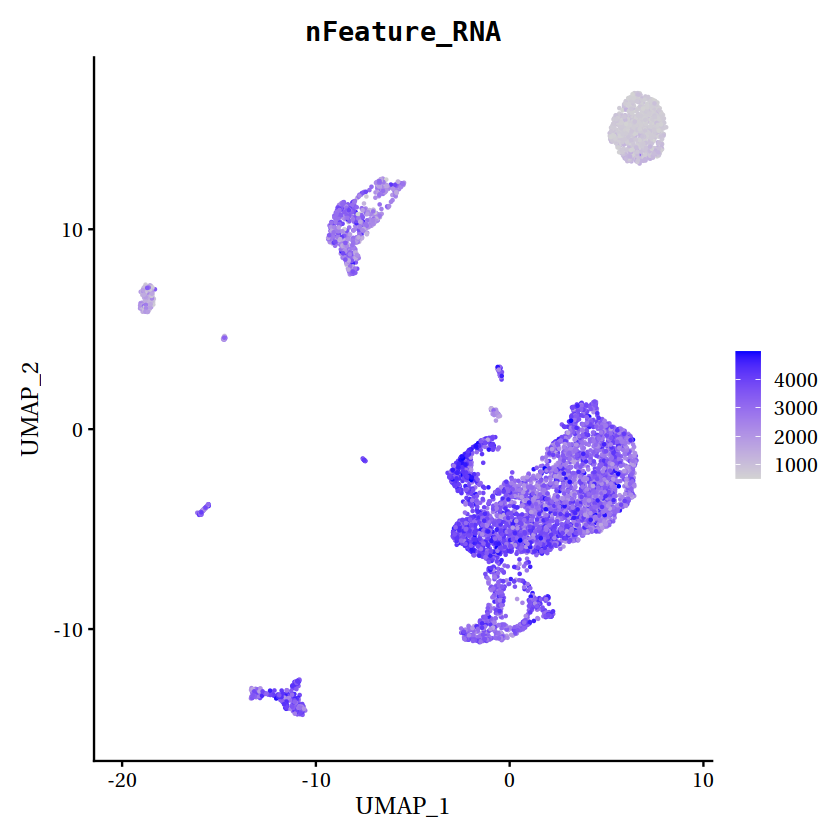

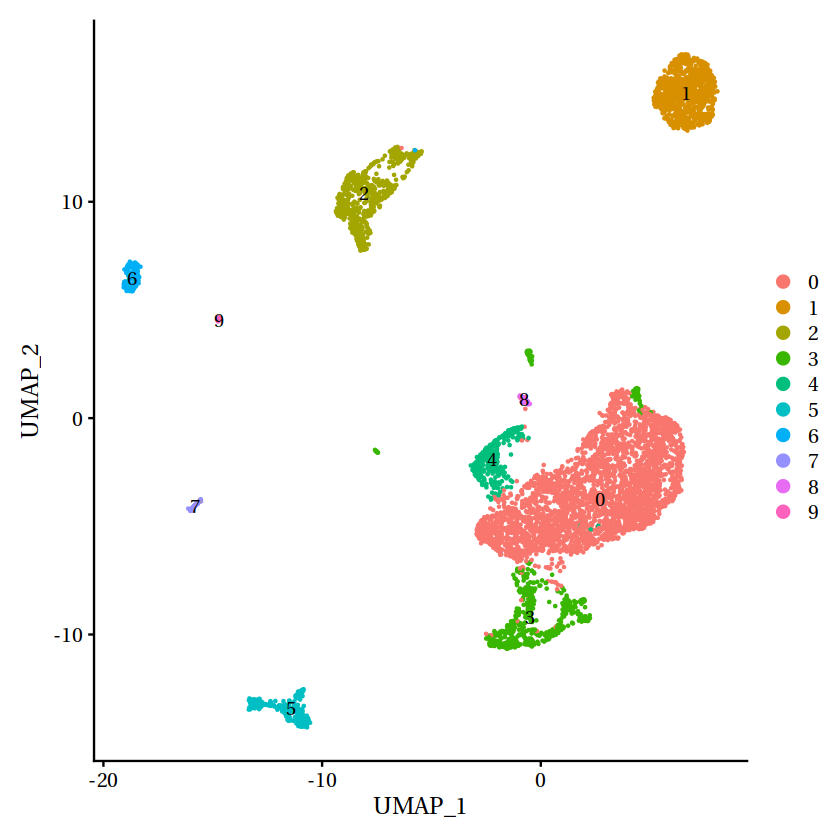

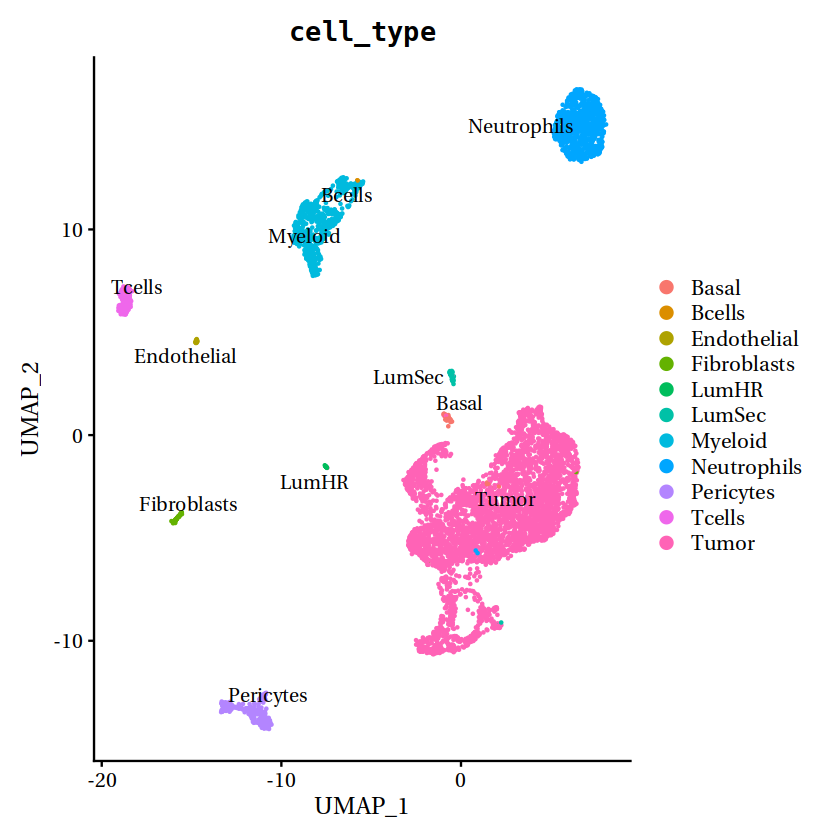

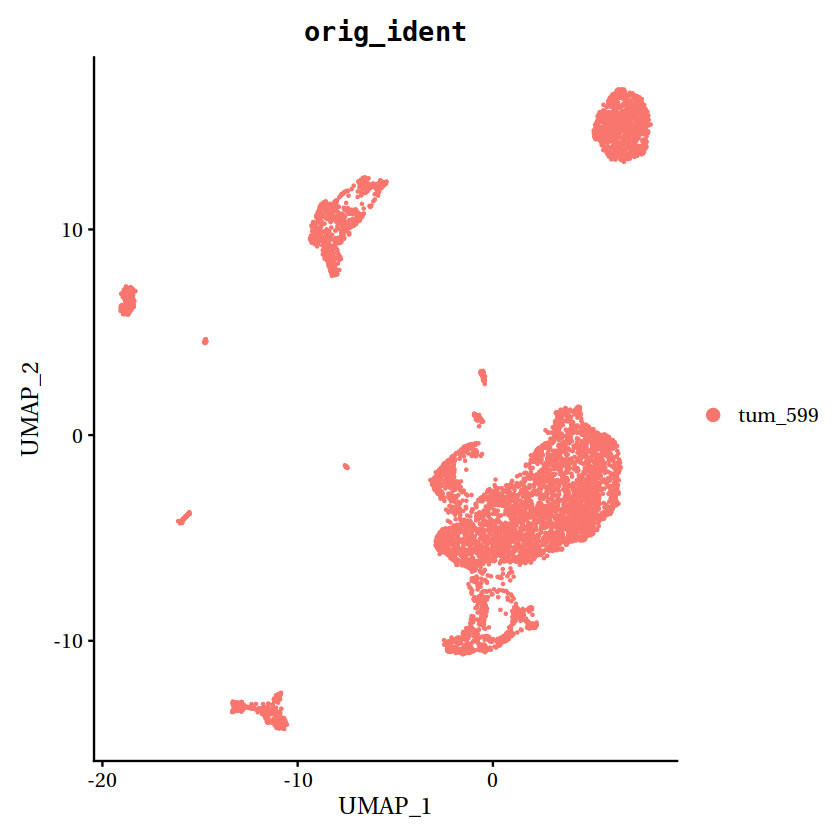

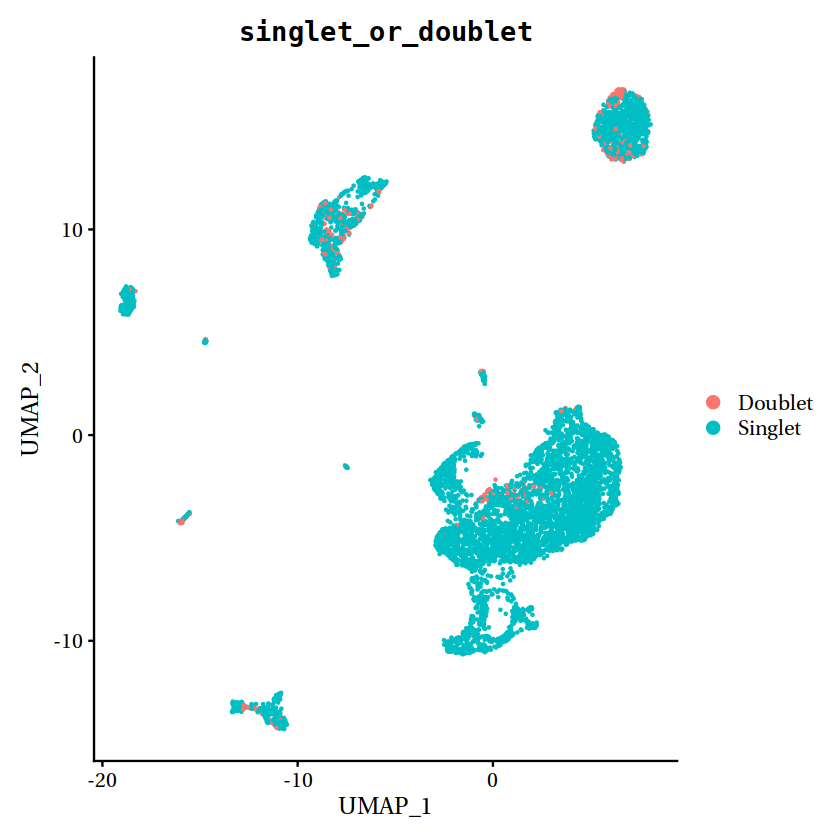

In [22]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

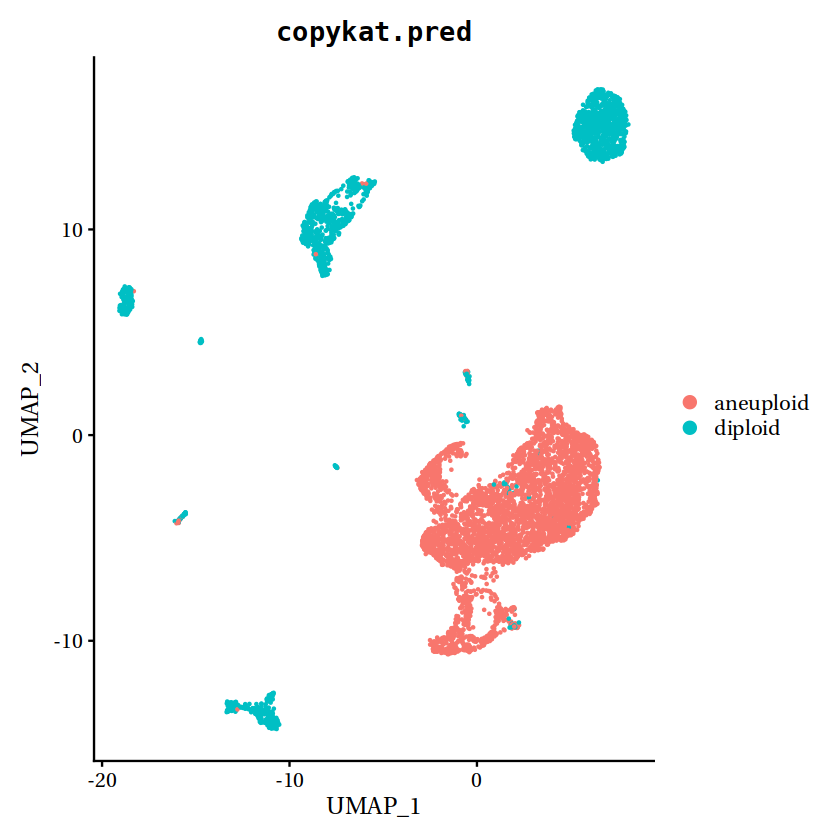

In [23]:
DimPlot(sub, group.by="copykat.pred")

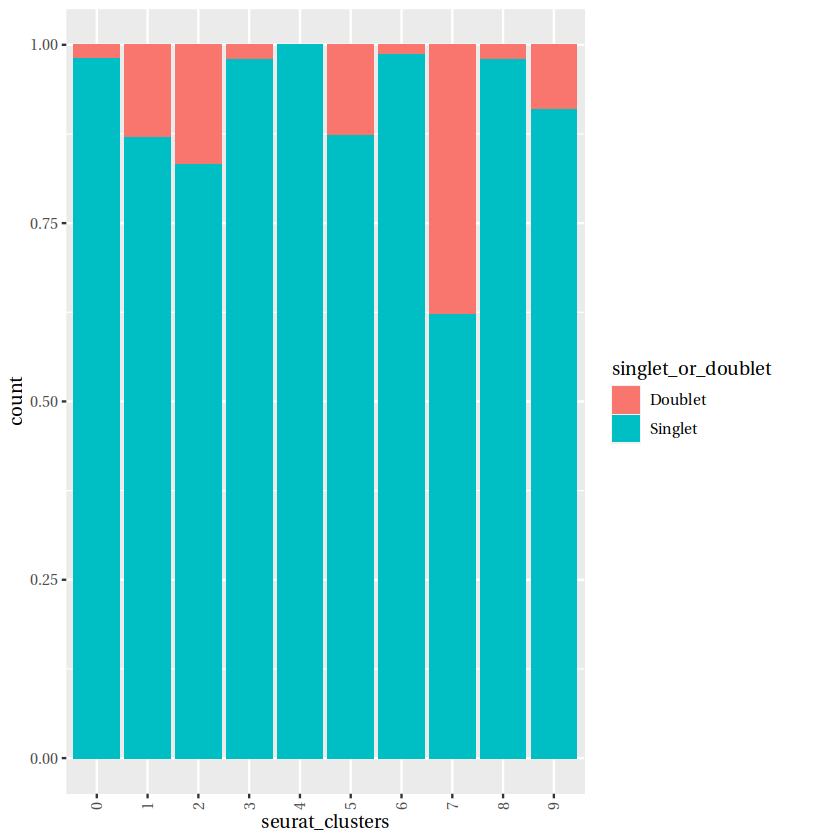

In [24]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

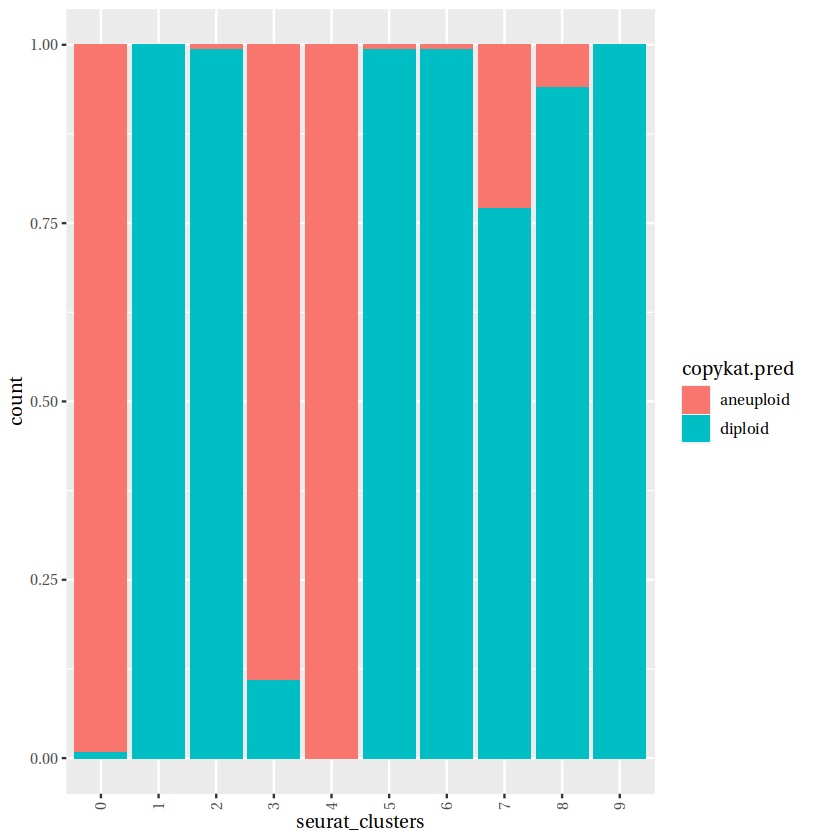

In [25]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## clean up (remove garbage)

In [26]:
obj$barcode <- colnames(obj)
obj <- subset(obj, subset = barcode %in% colnames(garbage), invert = T)

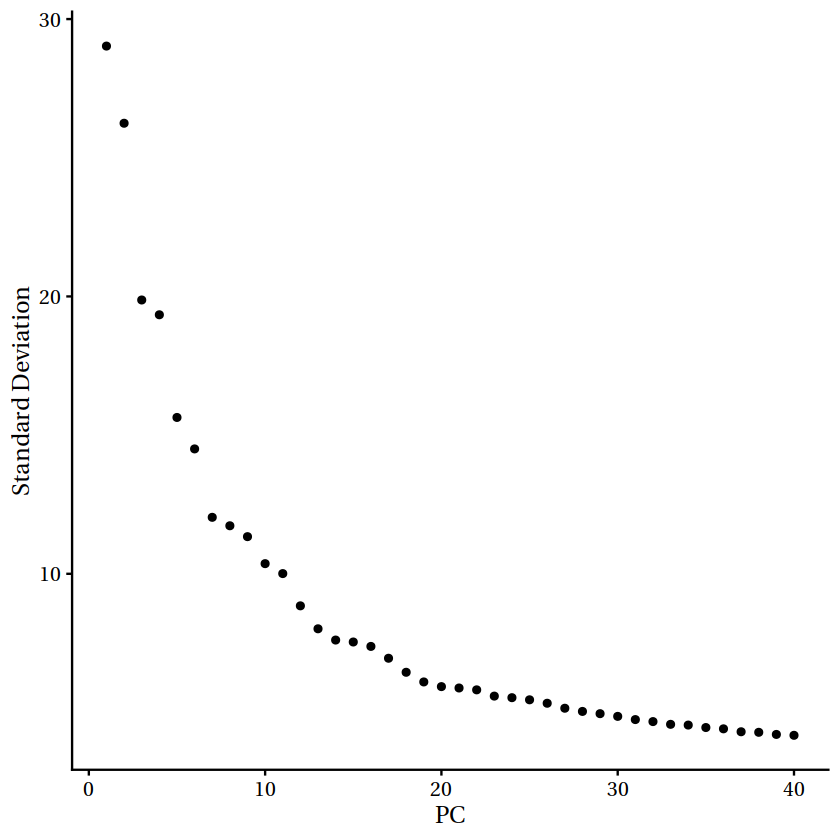

In [29]:
hvg <- read.csv("cellplex1.bigsur.hvg.csv", row.names = 1)

obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

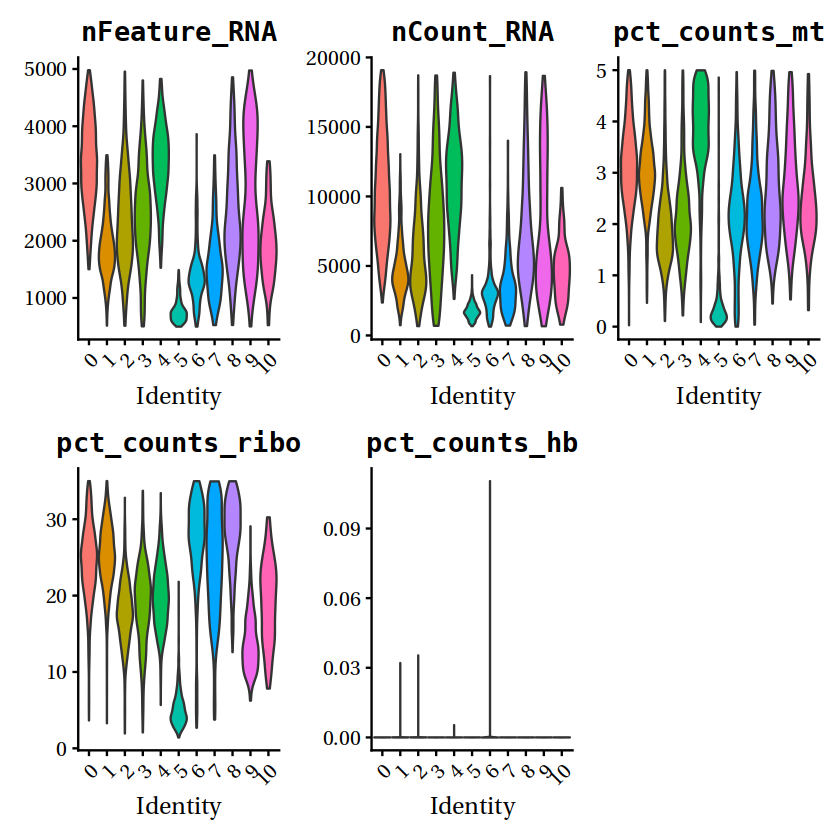

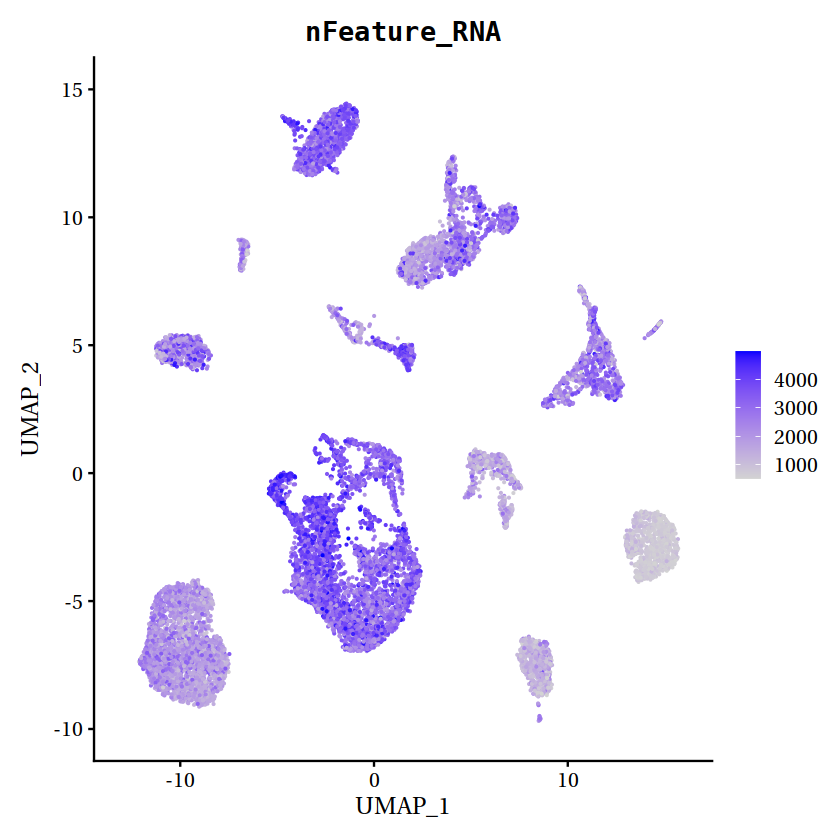

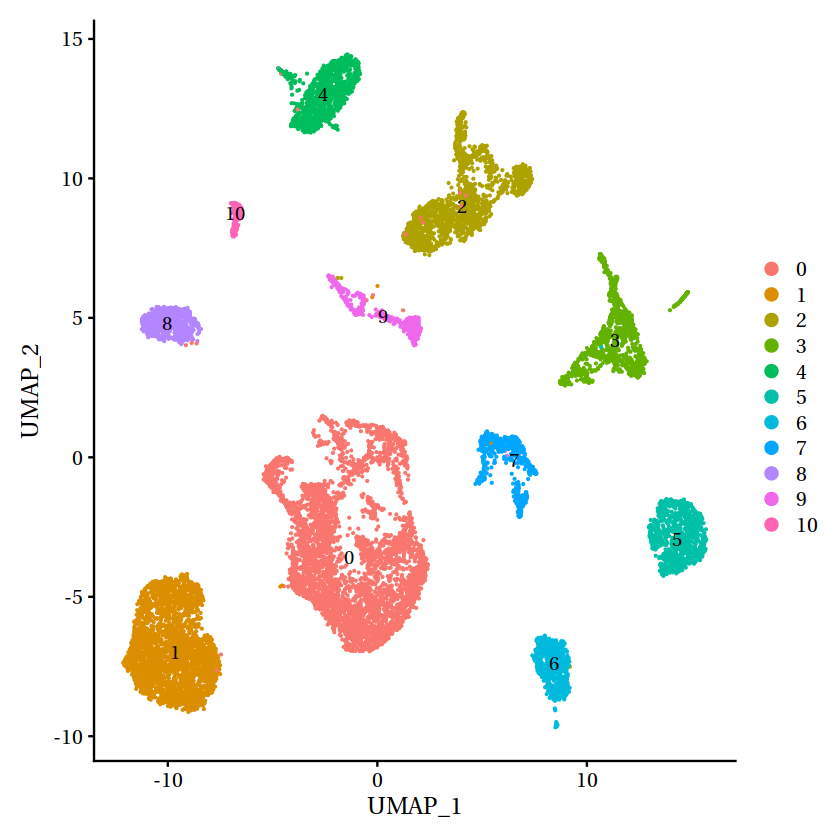

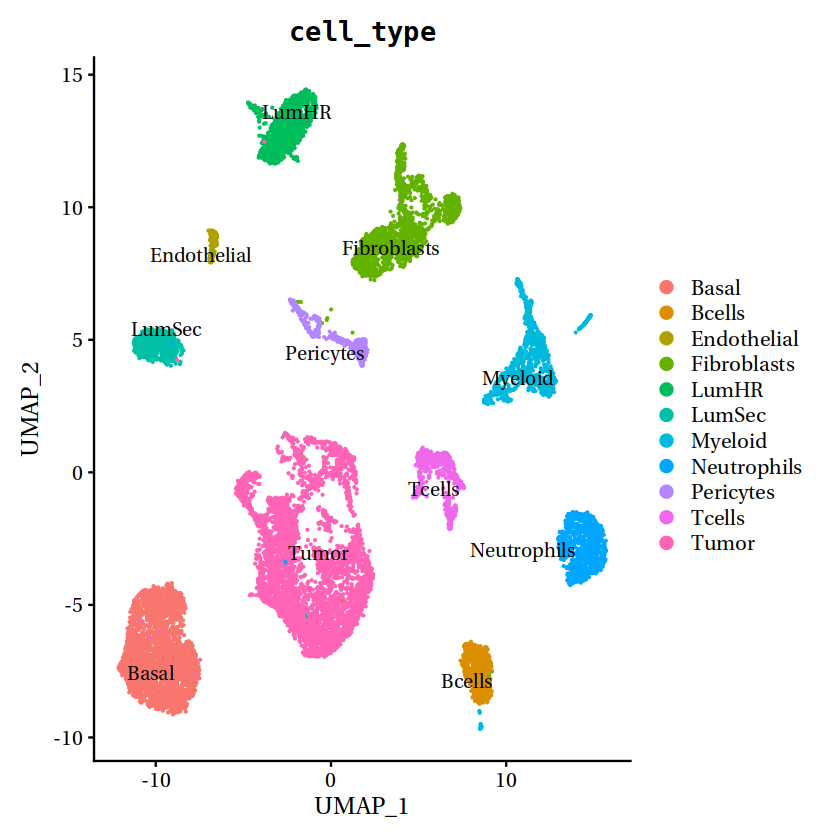

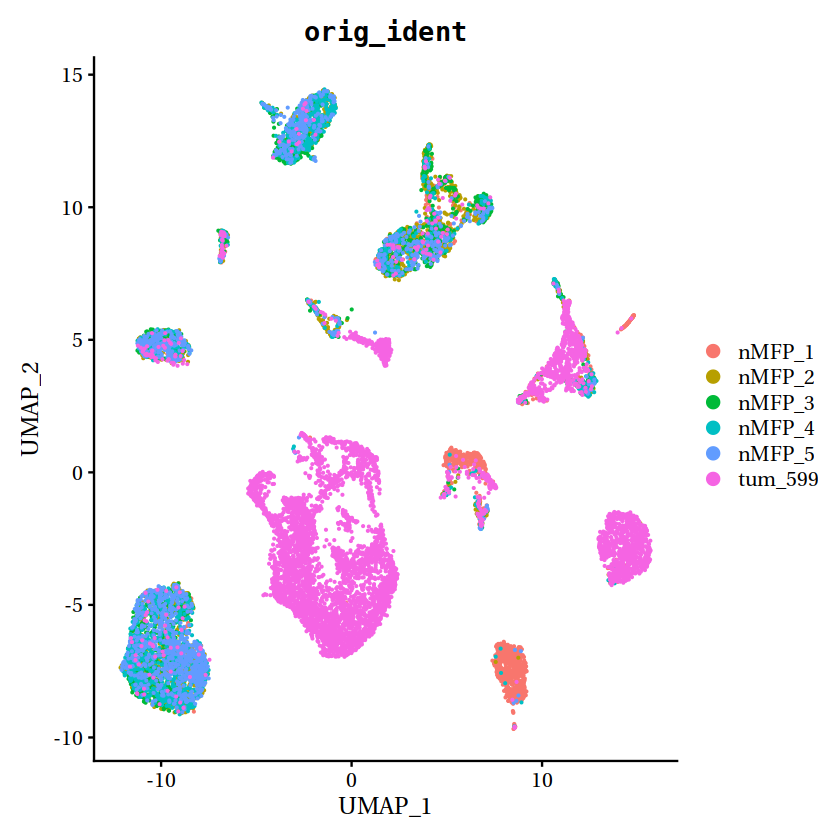

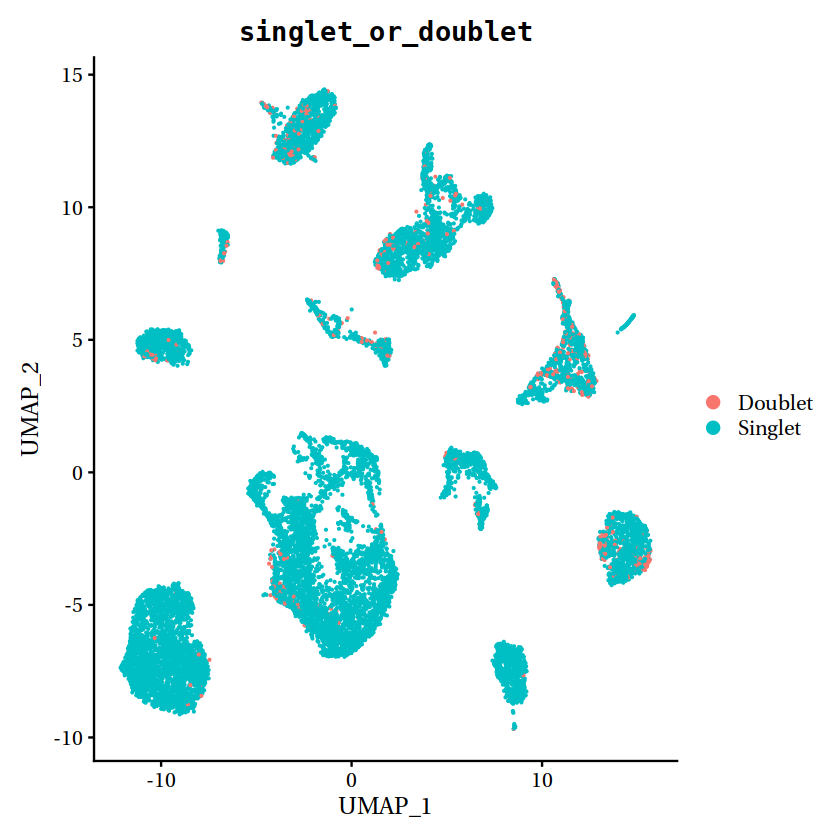

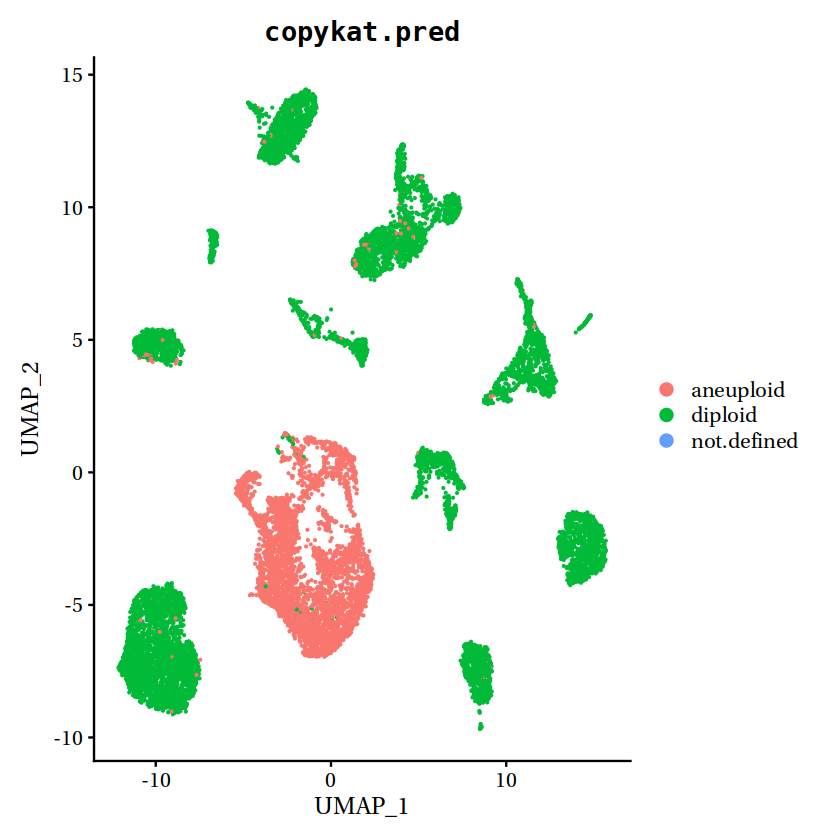

In [30]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)
DimPlot(obj, group.by = "singlet_or_doublet", label = F)
DimPlot(obj, group.by = "copykat.pred", label = F)

In [39]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 2250, WhichCells(obj, ident = c(6)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 1250, WhichCells(obj, ident = c(5)), invert = TRUE)

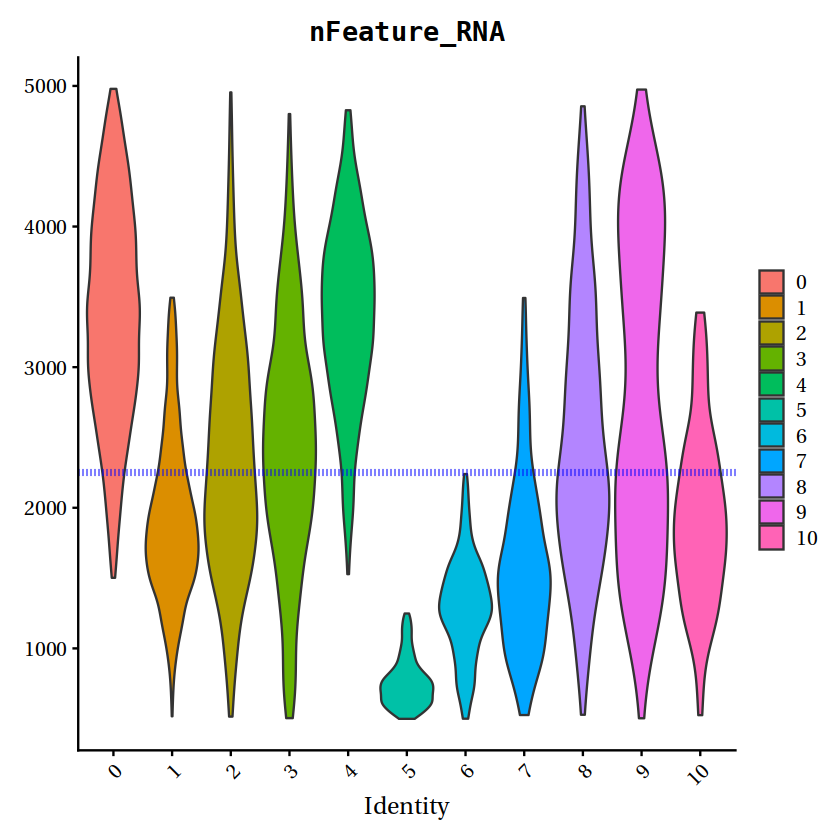

In [40]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 2250, linetype="dotted", 
                color = "blue", size=1.5)

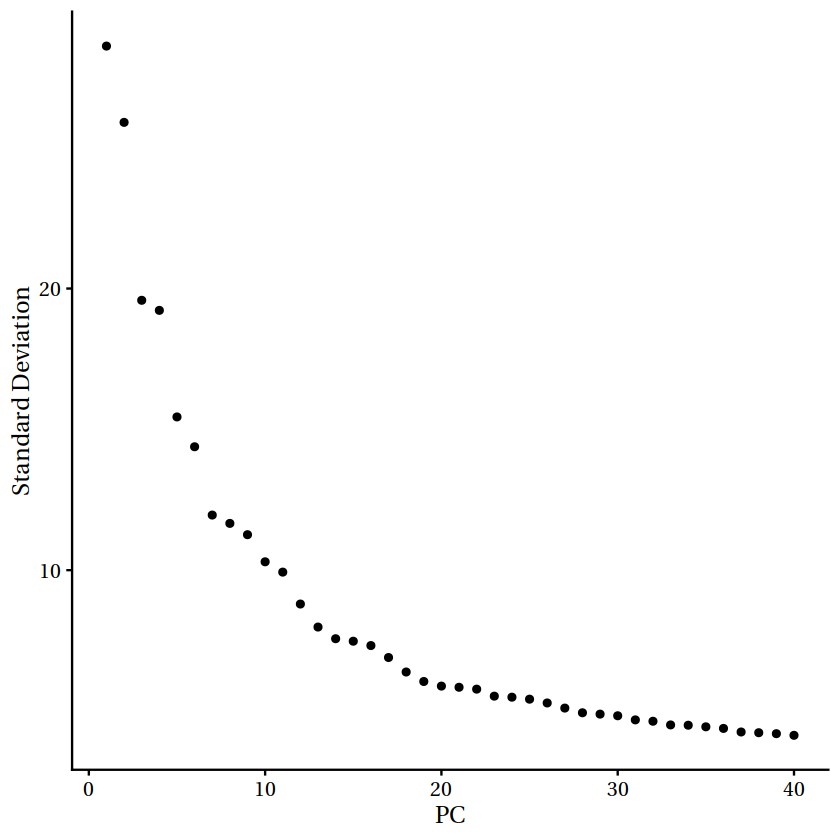

In [41]:
hvg <- read.csv("cellplex1.bigsur.hvg.csv", row.names = 1)

obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

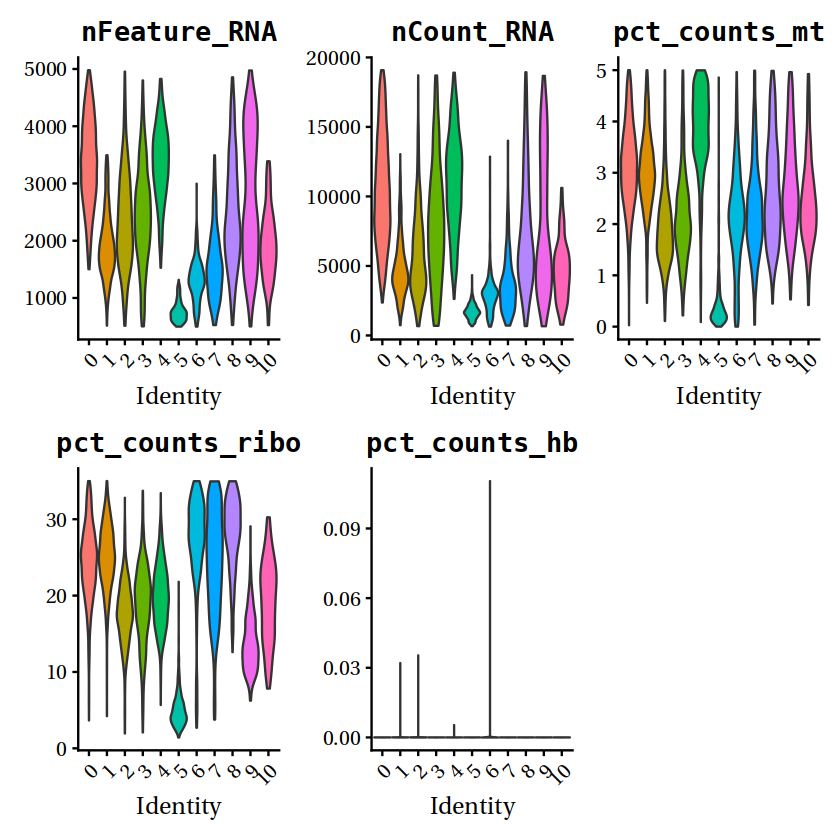

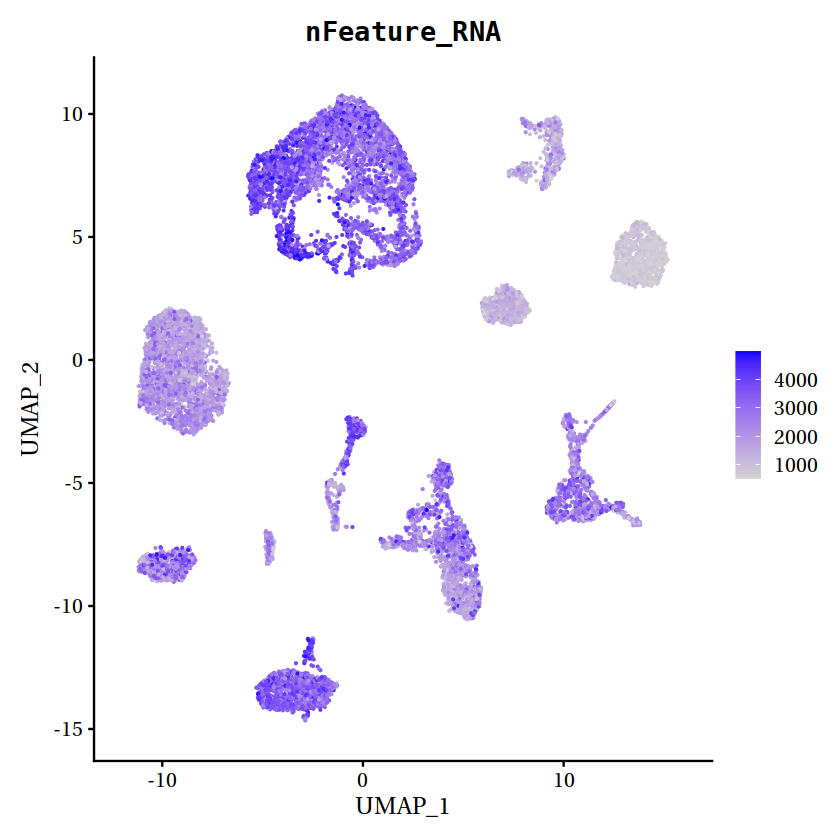

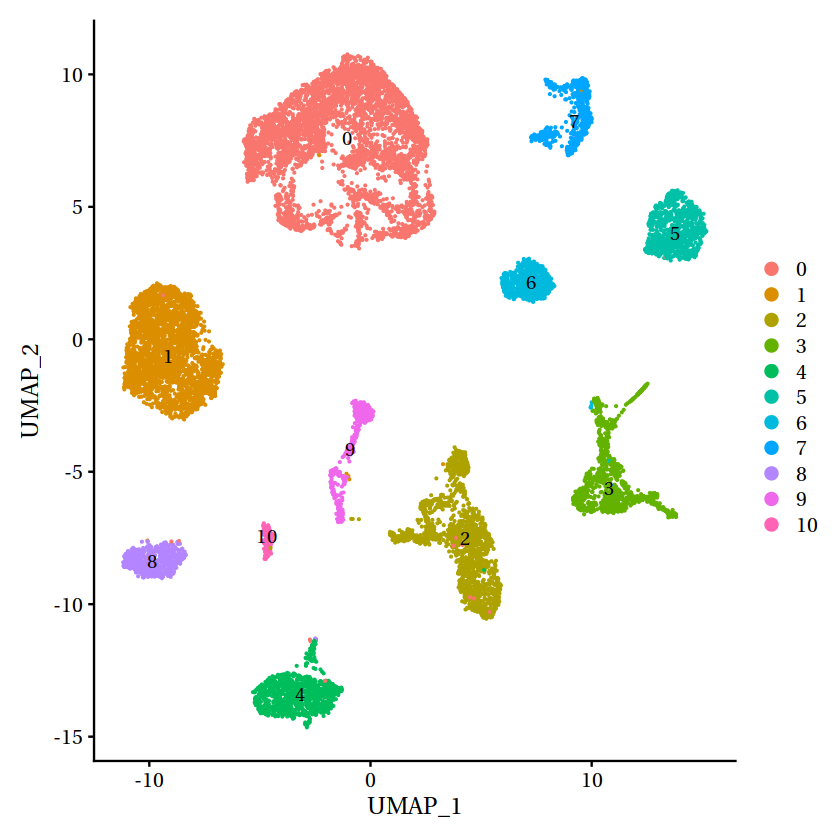

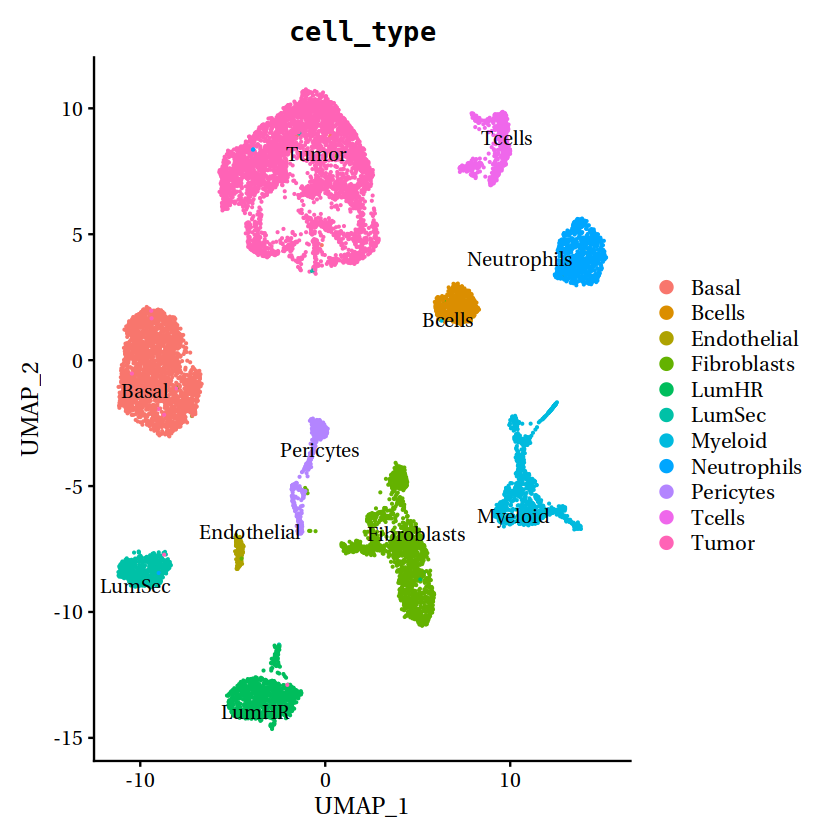

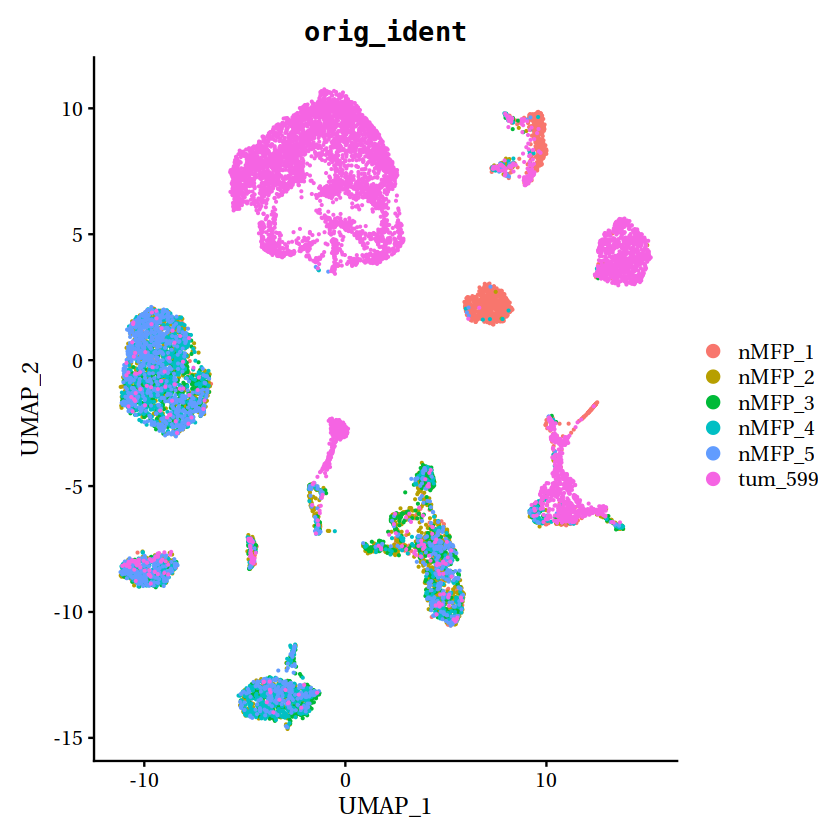

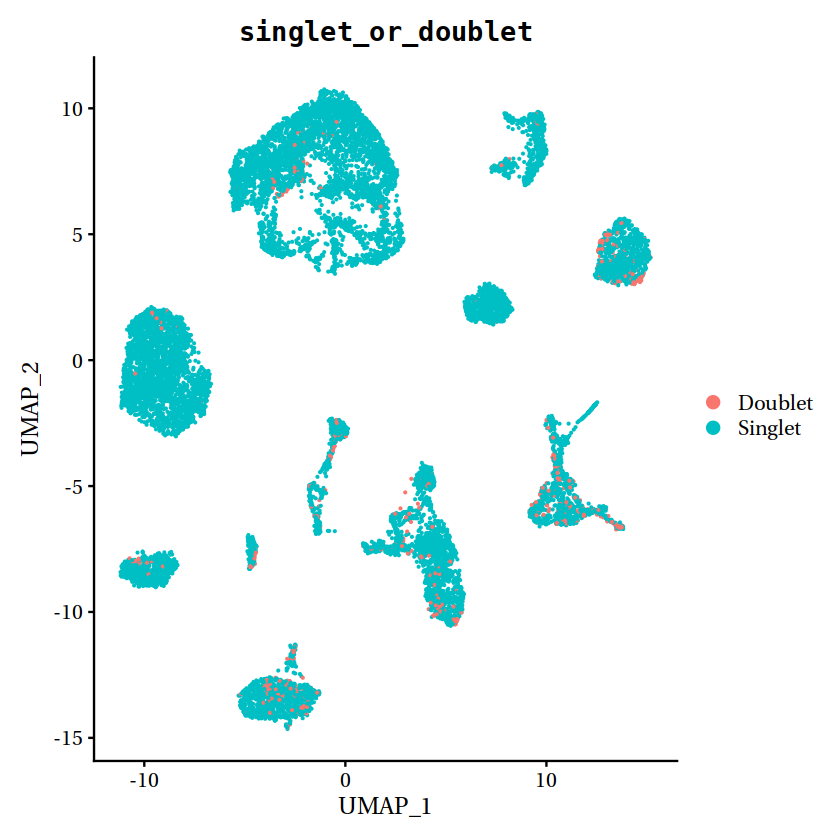

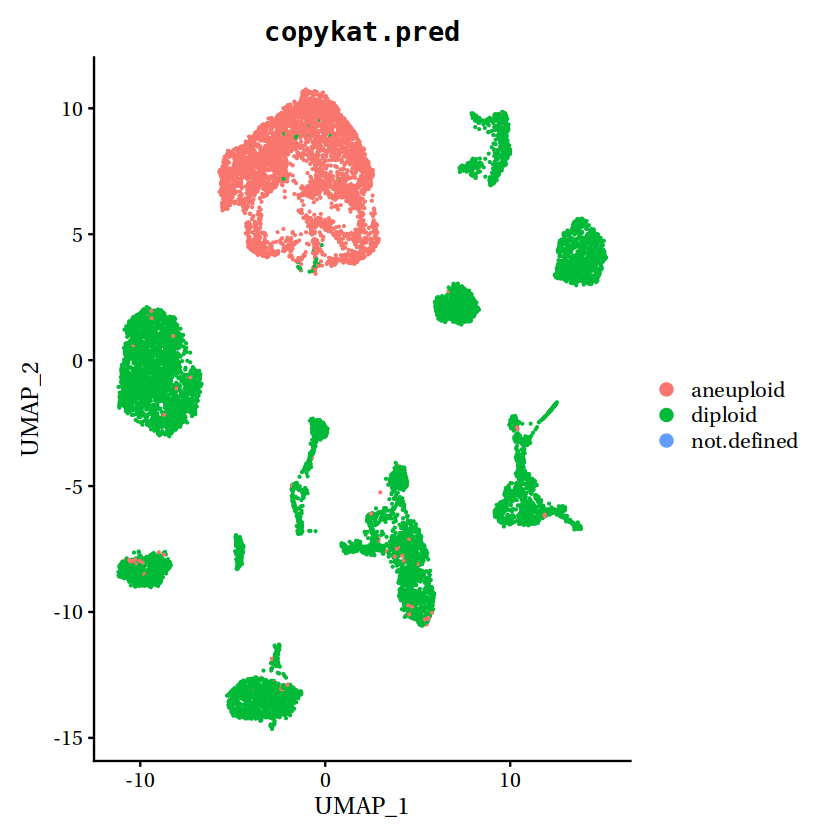

In [42]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)
DimPlot(obj, group.by = "singlet_or_doublet", label = F)
DimPlot(obj, group.by = "copykat.pred", label = F)

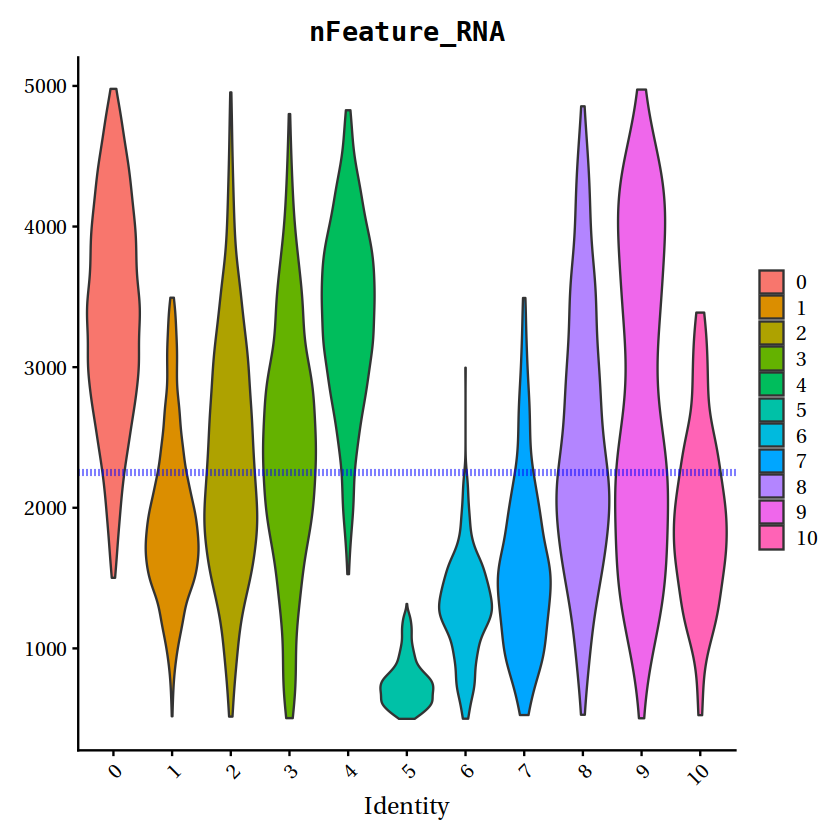

In [43]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 2250, linetype="dotted", 
                color = "blue", size=1.5)

In [44]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 2250, WhichCells(obj, ident = c(6)), invert = TRUE)

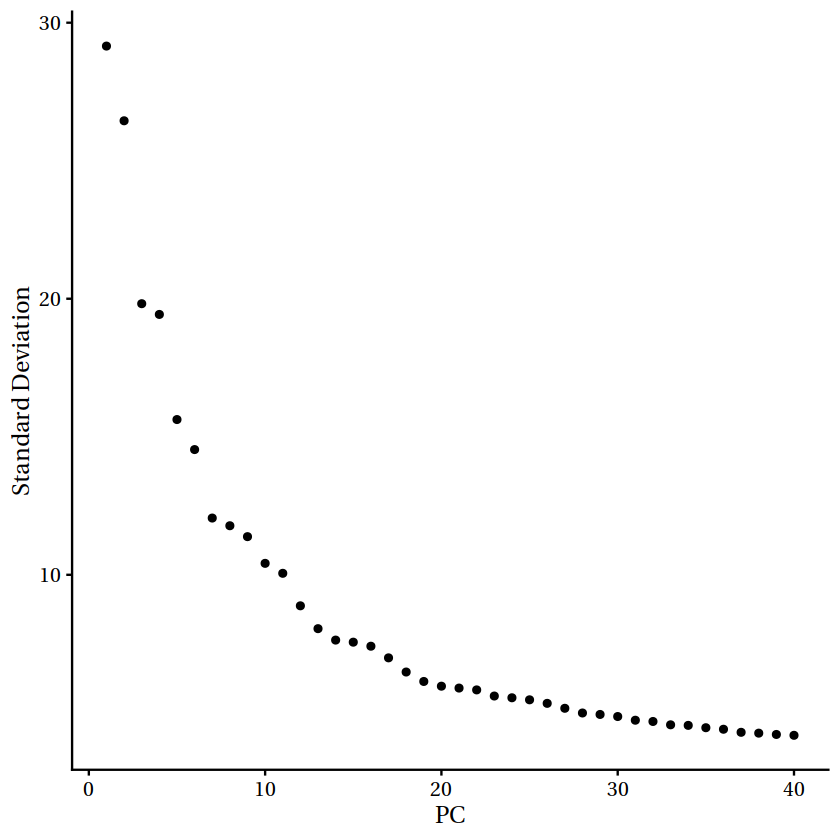

In [45]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

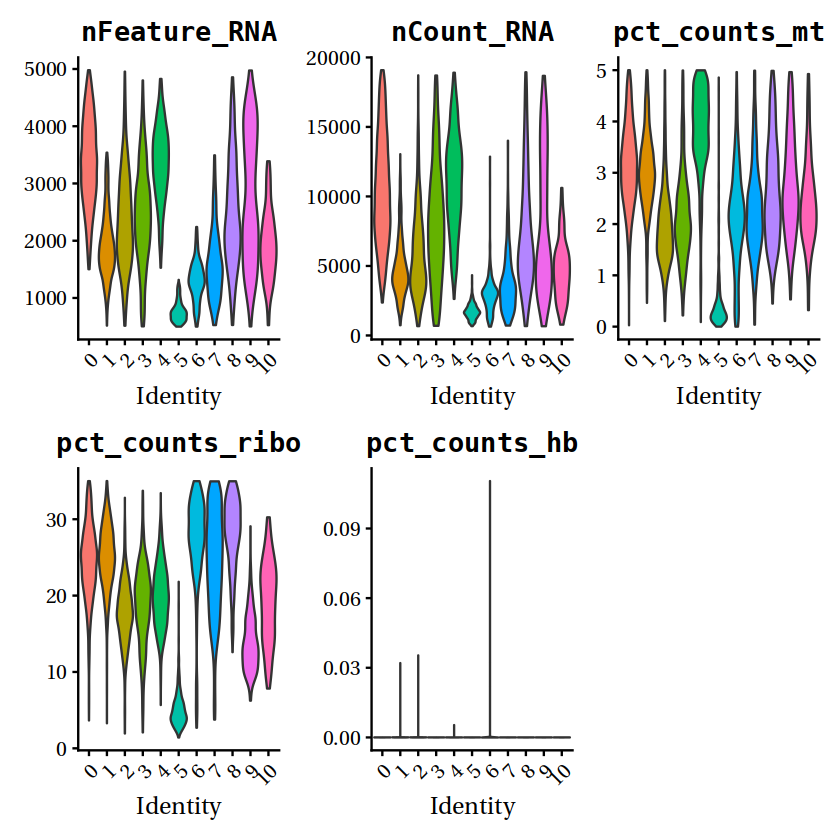

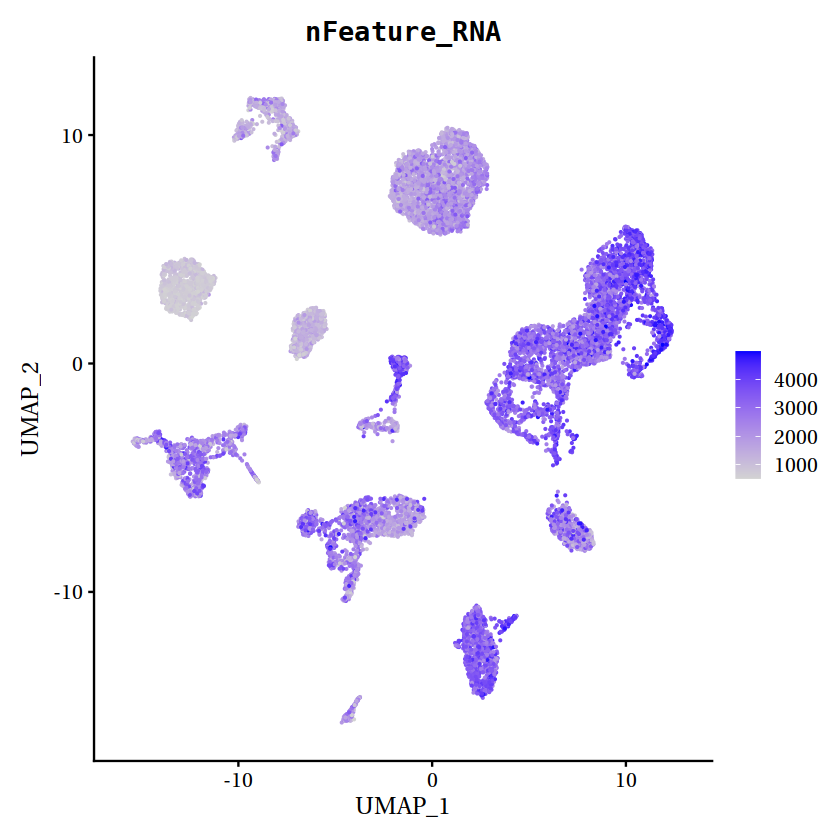

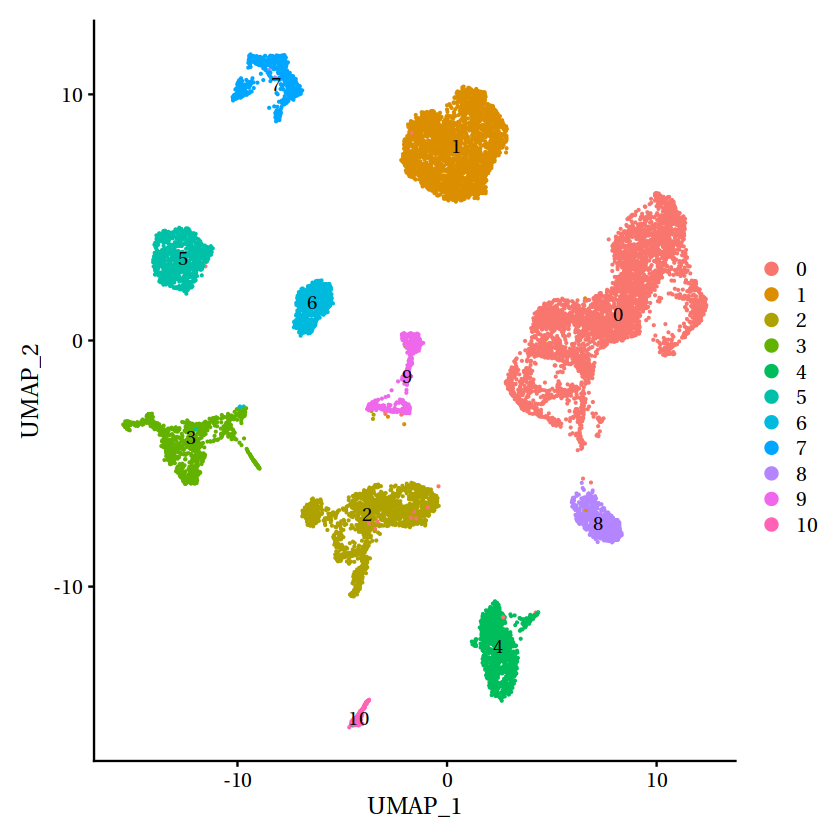

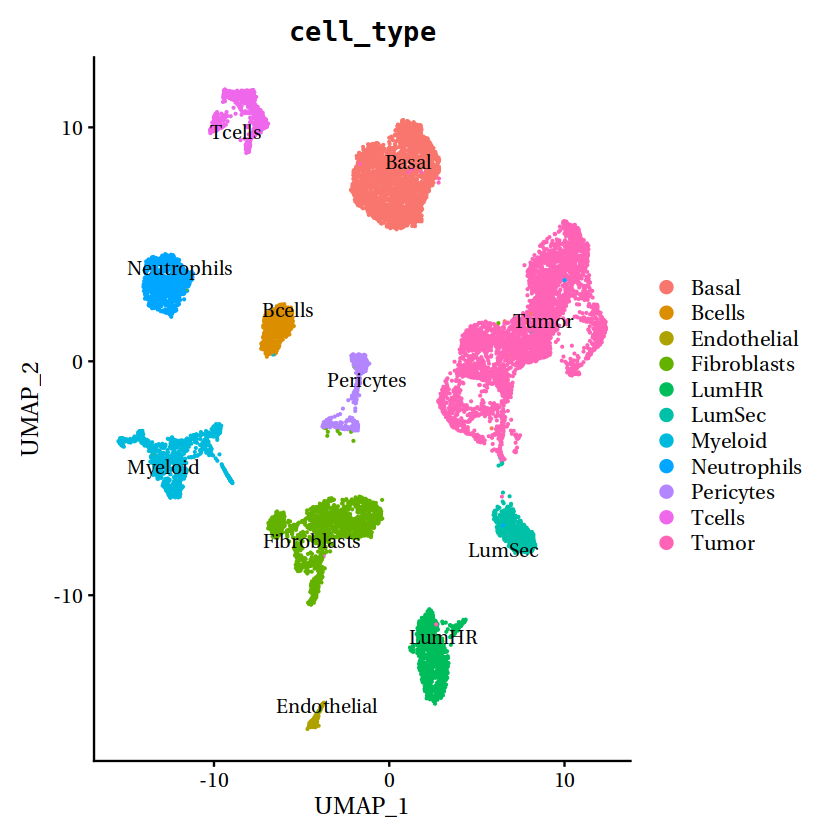

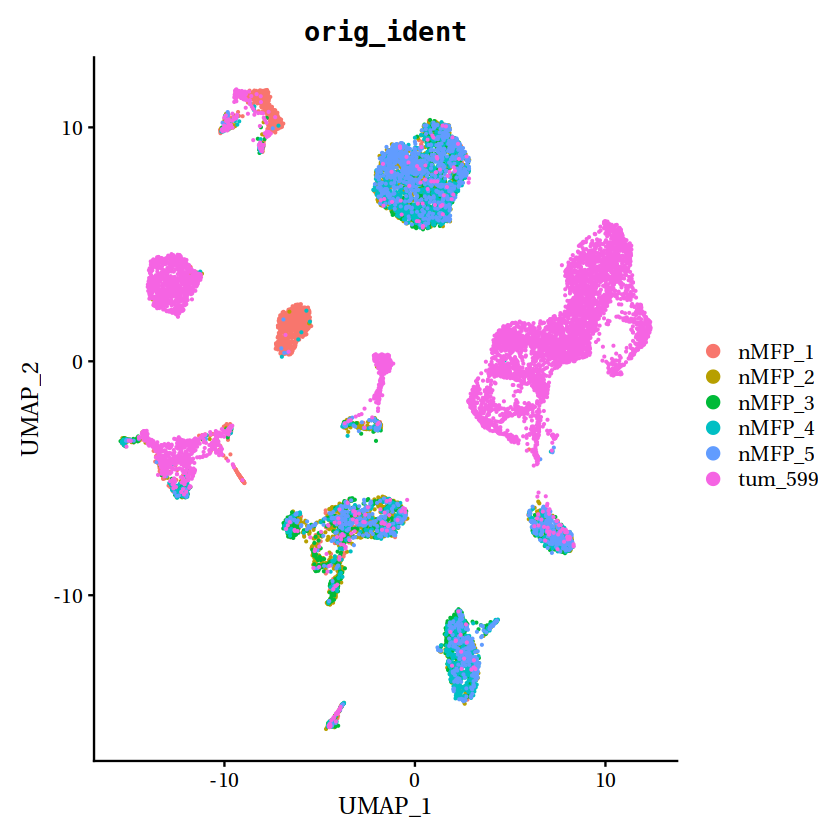

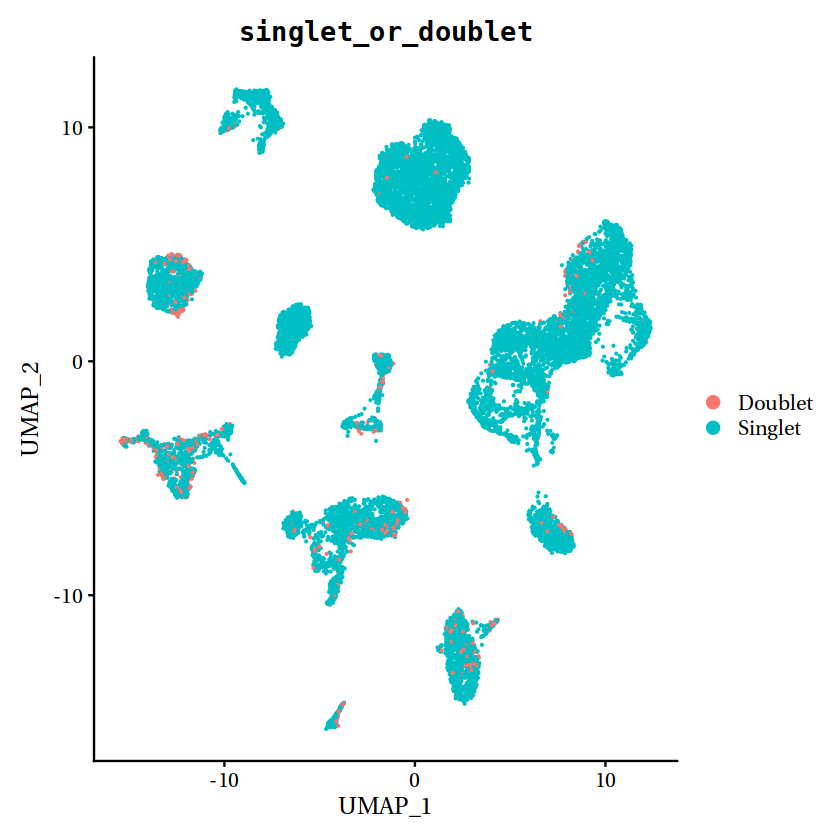

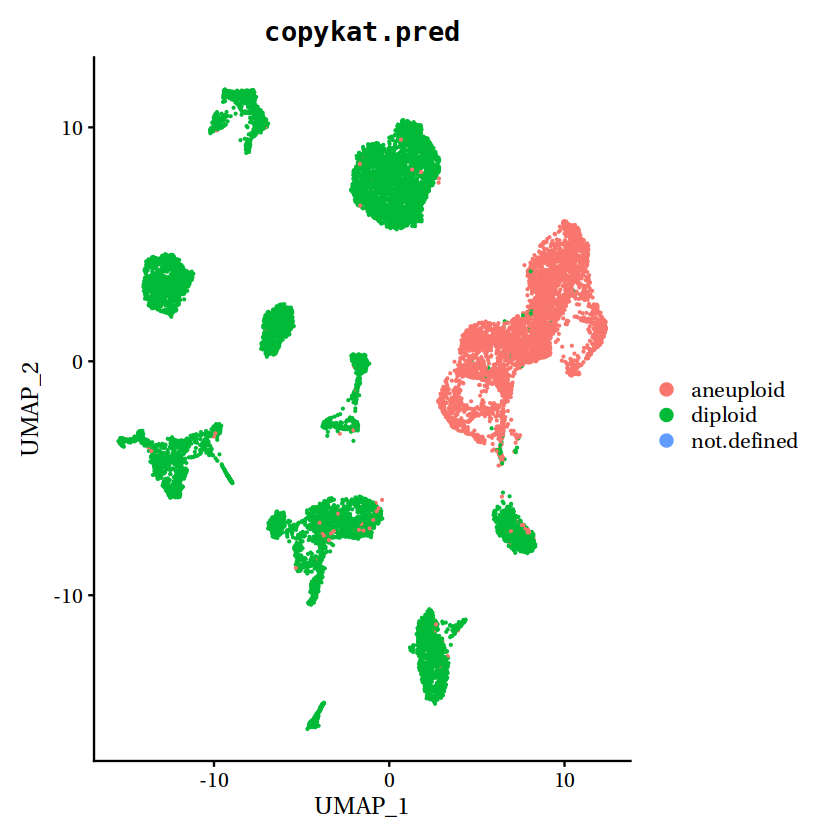

In [46]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)
DimPlot(obj, group.by = "singlet_or_doublet", label = F)
DimPlot(obj, group.by = "copykat.pred", label = F)

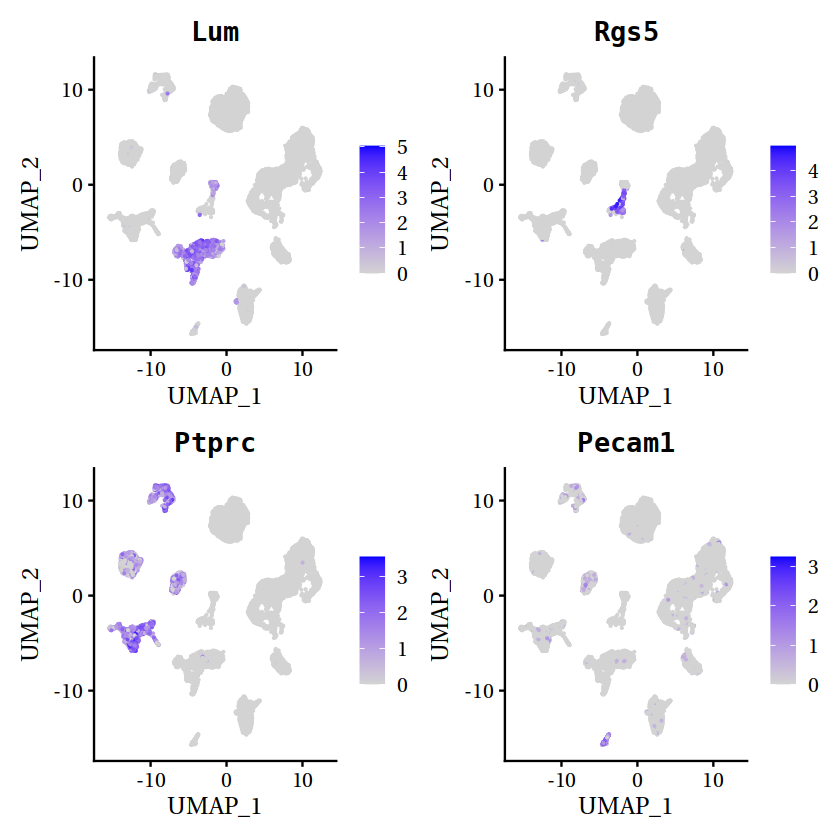

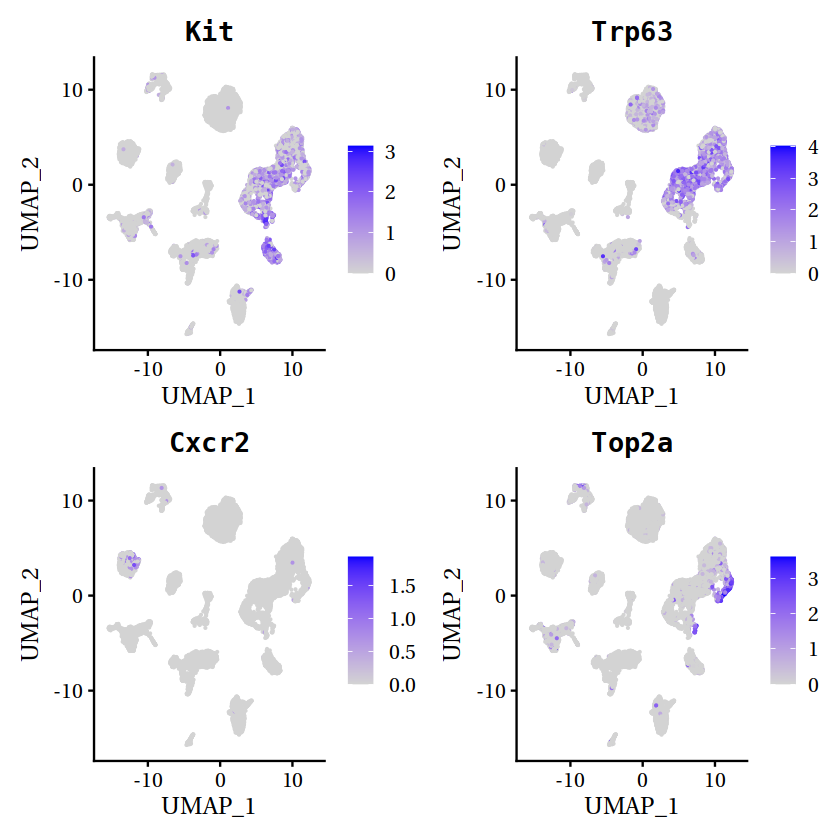

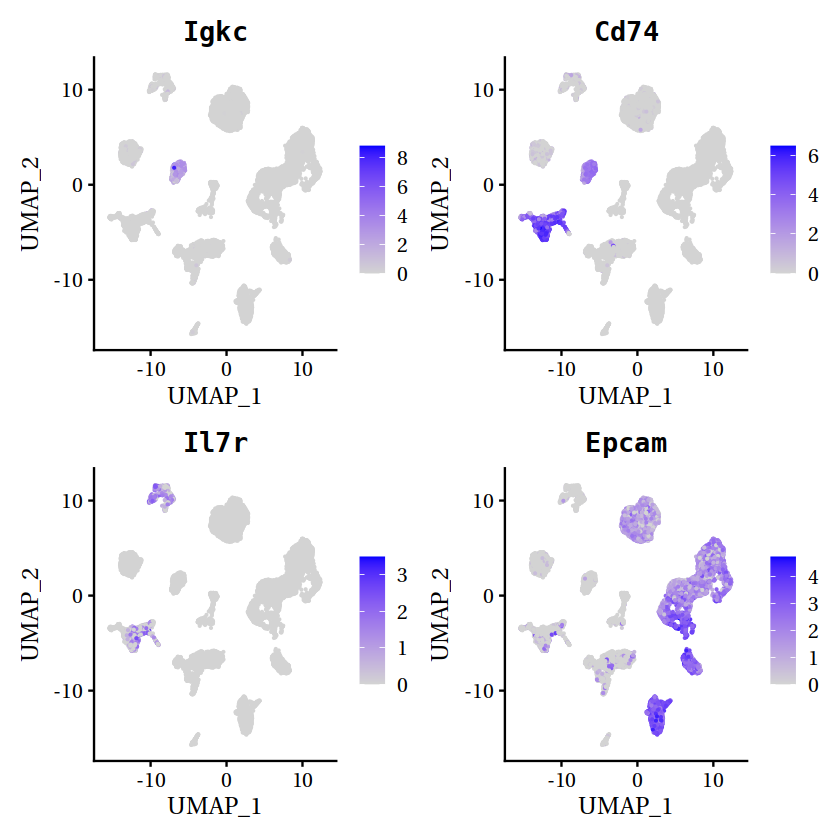

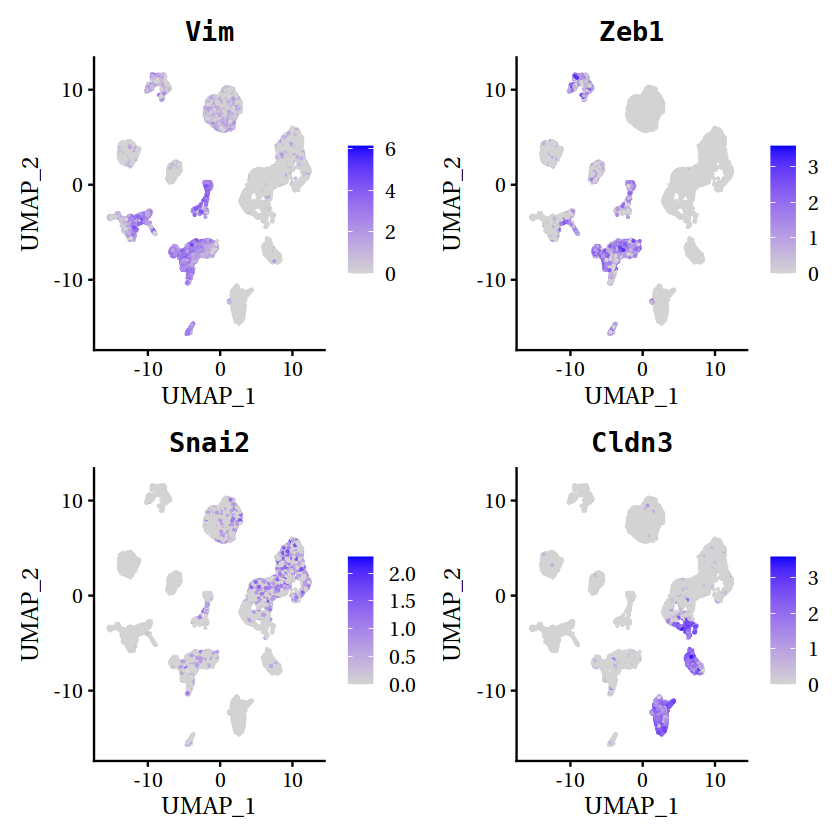

In [49]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

In [47]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Tumor", 
                            `1` = "Basal", 
                            `2` = "Fibroblasts", 
                            `3` = "Myeloid",
                            `4` = "LumHR",
                            `5` = "Neutrophils",
                            `6` = "Bcells", 
                            `7` = "Tcells", 
                            `8` = "LumSec", 
                            `9` = "Pericytes",
                            `10` = "Endothelial")
obj$cell_type <- obj@active.ident

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

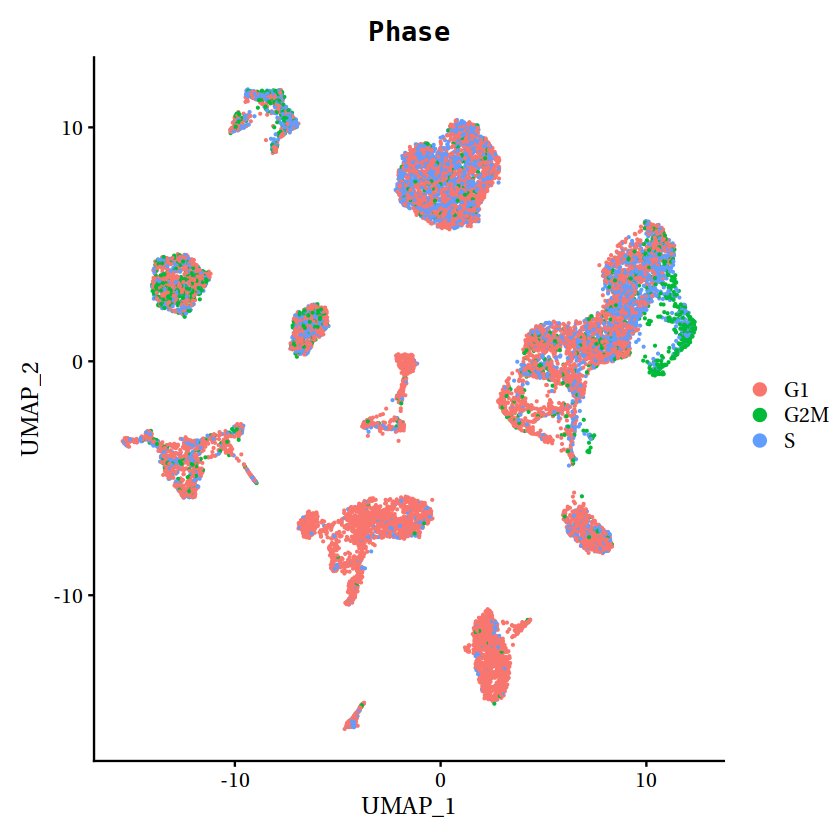

In [50]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

In [51]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Epithelial", 
                            `2` = "Stromal", 
                            `3` = "Immune",
                            `4` = "Epithelial",
                            `5` = "Immune",
                            `6` = "Immune", 
                            `7` = "Immune", 
                            `8` = "Epithelial", 
                            `9` = "Stromal",
                            `10` = "Stromal")
obj$cell_type_group <- obj@active.ident

In [52]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "wildtype", 
                            `nMFP_2` = "wildtype", 
                            `nMFP_3` = "wildtype",
                            `nMFP_4` = "wildtype",
                            `nMFP_5` = "wildtype",
                            `tum_599` = "mutant")
obj$genotype <- obj@active.ident

In [53]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "normal", 
                            `nMFP_2` = "normal", 
                            `nMFP_3` = "normal",
                            `nMFP_4` = "normal",
                            `nMFP_5` = "normal",
                            `tum_599` = "tumor_unrelated")
obj$condition_metastatic_burden <- obj@active.ident

In [54]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "normal", 
                            `nMFP_2` = "normal", 
                            `nMFP_3` = "normal",
                            `nMFP_4` = "normal",
                            `nMFP_5` = "normal",
                            `tum_599` = "tumor_8mm")
obj$condition_tumor_size_mm <- obj@active.ident

In [55]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "normal", 
                            `nMFP_2` = "normal", 
                            `nMFP_3` = "normal",
                            `nMFP_4` = "normal",
                            `nMFP_5` = "normal",
                            `tum_599` = "tumor")
obj$condition <- obj@active.ident

In [56]:
obj$cellplex <- "1"
obj$organ <- "mammary"
obj$transplant_status <- "original"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [57]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "intact", 
                            `nMFP_2` = "removed", 
                            `nMFP_3` = "removed",
                            `nMFP_4` = "removed",
                            `nMFP_5` = "removed",
                            `tum_599` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [58]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_1` = "wildtype_1", 
                            `nMFP_2` = "wildtype_1", 
                            `nMFP_3` = "wildtype_1",
                            `nMFP_4` = "wildtype_1",
                            `nMFP_5` = "wildtype_1",
                            `tum_599` = "tumor_1")
obj$mouse <- obj@active.ident

In [59]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [60]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [62]:
meta <- read.csv("cellplex1.adata.obs.metadata.csv", row.names=1)

In [63]:
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [64]:
saveRDS(obj, "cellplex1_soupX_doubletfinder_cnv_metadata.rds")